<a id="libraries"></a>
 <h1 style="text-align:center;">
       <b><span style="color:#800000">Second Notebook</span></b>
</h1>

<a id="libraries"></a>
# <b><span style='color:#0000FF'>A Comparative Analysis: </span><span style='color:#0000FF'> Machine Learning vs. Statistical Models</span></b>


## Part 2: Classification Analysis 

#### 🎯 Objective
This notebook continues our comparative series, shifting our focus from regression to classification.

- **Logistic Regression** (The "Interpretable" Linear Model): A classic statistical method that is highly explainable. We will use `the statsmodels library` to highlight its strength in statistical inference, allowing us to rigorously analyze the significance and impact of each feature.

- **Random Forest** (The "Powerful" Ensemble Model): A modern machine learning algorithm known for its high accuracy. We will use `the scikit-learn library` to demonstrate its strength in predictive performance, and we will explore its unique method of interpretation.


#### 📦 Datasets
We will use four standard classification datasets, chosen to provide a range of complexities, dimensions, and class types (binary vs. multi-class):

- **Iris**: A simple, low-dimensional, multi-class dataset.

- **Wine Classification**: A popular multi-class dataset with a moderate number of features.

- **Breast Cancer**: A clean, high-performing binary classification dataset.

- **Credit Default**: A more complex, "real-world" binary classification problem where interpretability is often as important as accuracy.

<a id="contents_tabel"></a>    
<div style="border-radius:10px; padding: 15px; background-color: #FFFFFF; font-size:130%; text-align:left">

<h2 align="left"><font color=#6a7f7a>Table of Contents:</font></h2>
    
* [Step 1 | Importing Necessary Libraries](#libraries)
   
* [Step 2 | Exploratory Data Analysis (EDA) for all  📦 Datasets ](#eda) 
    - [Step 2.1 | EDA for Iris Dataset](#eda1) 
    - [Step 2.2 | EDA for Wine Classification Dataset](#eda2)
    - [Step 2.3 | EDA for Breast Cancer Dataset](#eda3) 
    - [Step 2.4 | EDA for Credit Default Dataset](#eda4) 
    
* [Step 3 |  Data Preprocessing ](#DP) 
    - [Step 3.1 | 🔧 Data Preprocessing for Iris Dataset](#DP1) 
    - [Step 3.2 | 🔧 Data Preprocessing for Wine Classification Dataset](#DP2)
    - [Step 3.3 | 🔧 Data Preprocessing for Breast Cancer Dataset](#DP3) 
    - [Step 3.4 | 🔧 Data Preprocessing for Credit Default Dataset](#DP4)
    
* [Step 4 |  Model Training, Evaluation, and Comparison ](#Ml) 
    - [Step 4.1 |  Iris Dataset](#Ml1) 
    - [Step 4.2 |  Wine Classification Dataset](#Ml2)
    - [Step 4.3 |  Breast Cancer Dataset](#Ml3)
    - [Step 4.4 |  Credit Default Dataset](#Ml4)
    


<a id="libraries"></a>
# <b><span style='color:#09ba80'>Step 1 |</span><span style='color:#34e3ae'> Importing Necessary Libraries</span></b>
- This section imports all necessary packages, groups them by function, and loads the datasets we will use for the analysis.
⬆️ [Tabel of Contents](#contents_tabel)

In [1]:
# Import necessary libraries

import numpy as np #The fundamental package for numerical computing in Python.
import pandas as pd # A library for high-performance, easy-to-use data structures and data analysis.
import matplotlib.pyplot as plt #The primary library for creating static, animated, and interactive visualizations.
import seaborn as sns # A high-level data visualization library based on matplotlib, providing attractive statistical graphics.
import time # A library that provides classes and functions for the estimation of many different statistical models
from scipy import stats

# Warnings: Used to control how warning messages are handled (we will ignore them for cleaner output).
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler



<a id="eda"></a>
# <b><span style='color:#09ba80'>Step 2 | </span><span style='color:#34e3ae'>Exploratory Data Analysis (EDA) for all  📦 Datasets  </span></b>
⬆️ [Tabel of Contents](#contents_tabel)

<a id="eda1"></a>
## <b><span style='color:#299617'>Step 2.1 | </span><span style='color:#299617'>EDA for Iris Dataset</span></b>
⬆️ [Tabel of Contents](#contents_tabel)

<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.1.1 | </span><span style='color:#800000'> Load dataset, Create DataFrame  </span></b>

In [2]:
print("=" * 80)

# Load dataset
from sklearn.datasets import load_iris
data = load_iris()
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_names

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['species'] = [target_names[i] for i in y]

print(f"\n1. Dataset Overview:")
print(f"   - Shape: {df.shape[0]} samples × {df.shape[1]} features (including target)")
print(f"   - Features: {len(feature_names)}")
print(f"   - Target variable: Species (Iris classification)")
print(f"   - Classes: {len(np.unique(y))} ({', '.join(target_names)})")

print(f"\n2. Feature Names:")
for i, name in enumerate(feature_names, 1):
    print(f"   {i}. {name}")

print(f"\n3. Basic Statistics:")
print(df[feature_names].describe().round(2))

print(f"\n4. Data Types:")
print(df.dtypes)

print(f"\n5. Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ No missing values found")
else:
    print(missing[missing > 0])

print(f"\n6. Class Distribution:")
unique_classes, counts = np.unique(y, return_counts=True)
for cls, count, name in zip(unique_classes, counts, target_names):
    print(f"   - {name} (Class {cls}): {count} samples ({100*count/len(y):.1f}%)")
print(f"   - Balanced: {'Yes' if len(set(counts)) == 1 else 'No'}")

print(f"\n7. Feature Statistics by Class:")
for i, name in enumerate(target_names):
    print(f"\n   {name}:")
    class_data = df[df['target'] == i][feature_names]
    print(f"      Mean: {class_data.mean().round(2).tolist()}")
    print(f"      Std:  {class_data.std().round(2).tolist()}")




1. Dataset Overview:
   - Shape: 150 samples × 6 features (including target)
   - Features: 4
   - Target variable: Species (Iris classification)
   - Classes: 3 (setosa, versicolor, virginica)

2. Feature Names:
   1. sepal length (cm)
   2. sepal width (cm)
   3. petal length (cm)
   4. petal width (cm)

3. Basic Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%                 5.80              3.00               4.35   
75%                 6.40              3.30               5.10   
max                 7.90              4.40               6.90   

       petal width (cm)  
count            150.00  
mean               1.20  
std   

<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.1.2 | </span><span style='color:#800000'>  Visualizations </span></b>

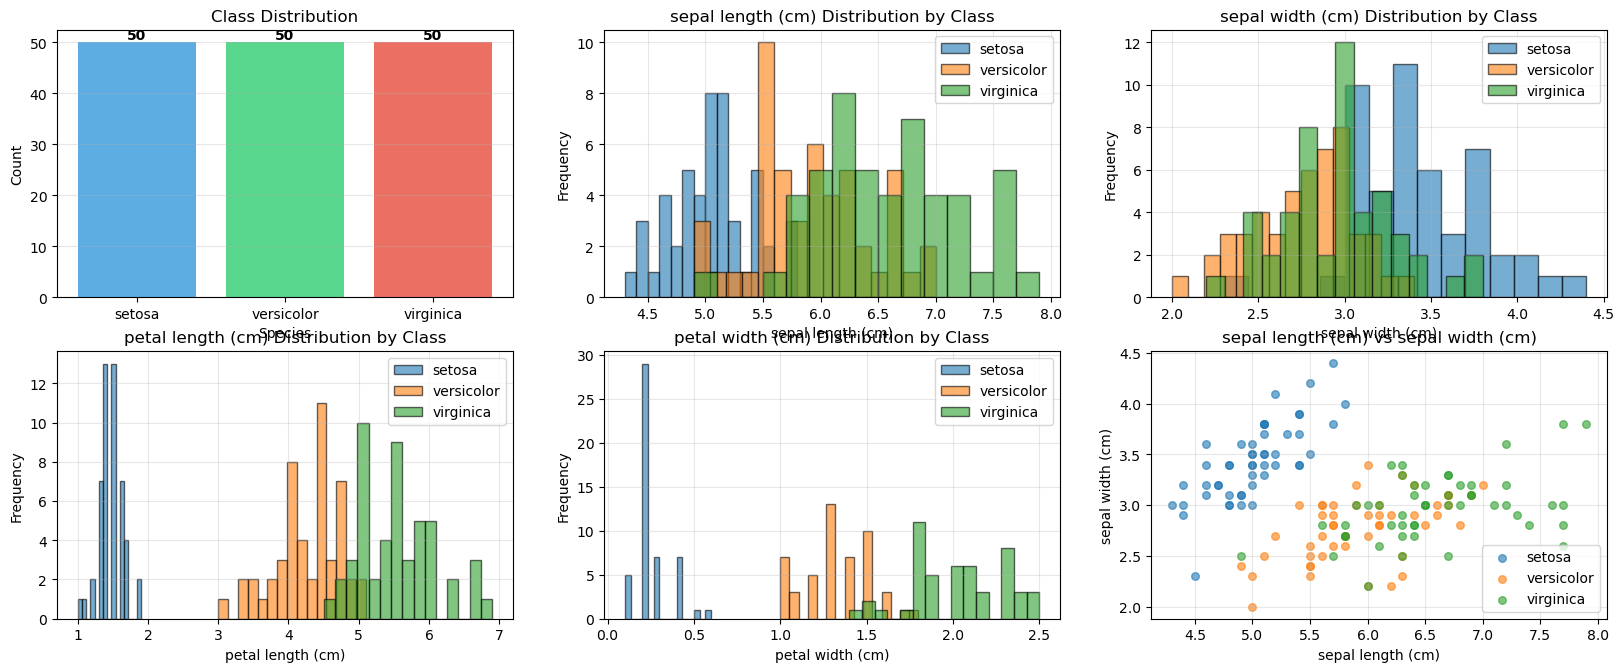

In [3]:
# Visualizations
fig = plt.figure(figsize=(20, 16))

# 1. Class distribution
ax1 = plt.subplot(4, 3, 1)
class_counts = pd.Series(y).value_counts().sort_index()
bars = ax1.bar(target_names, class_counts.values, alpha=0.8, color=['#3498db', '#2ecc71', '#e74c3c'])
ax1.set_xlabel('Species')
ax1.set_ylabel('Count')
ax1.set_title('Class Distribution')
for bar, count in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{count}', ha='center', va='bottom', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 2-5. Feature distributions by class
for i, feature in enumerate(feature_names[:4], 2):
    ax = plt.subplot(4, 3, i)
    for j, species in enumerate(target_names):
        ax.hist(df[df['species'] == species][feature], bins=15, alpha=0.6, 
                label=species, edgecolor='black')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{feature} Distribution by Class')
    ax.legend()
    ax.grid(True, alpha=0.3)

# 6. Pair plot (sample of features)
ax6 = plt.subplot(4, 3, 6)
for j, species in enumerate(target_names):
    ax6.scatter(df[df['species'] == species][feature_names[0]], 
               df[df['species'] == species][feature_names[1]], 
               alpha=0.6, label=species, s=30)
ax6.set_xlabel(feature_names[0])
ax6.set_ylabel(feature_names[1])
ax6.set_title(f'{feature_names[0]} vs {feature_names[1]}')
ax6.legend()
ax6.grid(True, alpha=0.3)



<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.1.3 | </span><span style='color:#800000'>   Correlation matrix </span></b>

Text(0.5, 1.0, 'Feature Correlation Matrix')

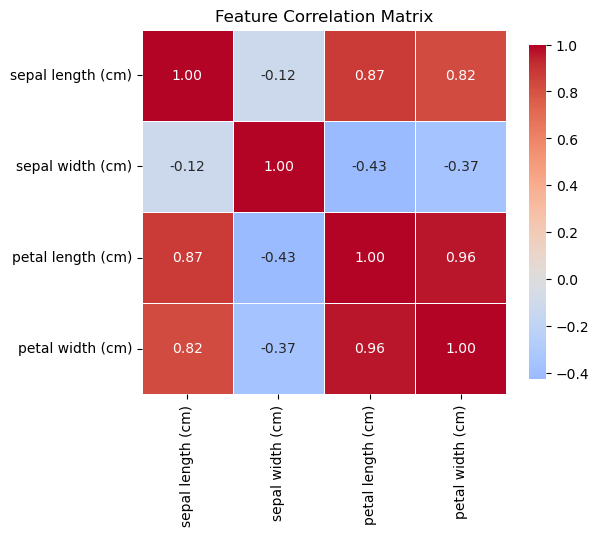

In [4]:
# Correlation matrix
fig = plt.figure(figsize=(20, 25))
ax7 = plt.subplot(4, 3, 7)
corr_matrix = df[feature_names].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax7)
ax7.set_title('Feature Correlation Matrix')



<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.1.4 | </span><span style='color:#800000'>  Target vs Features </span></b>

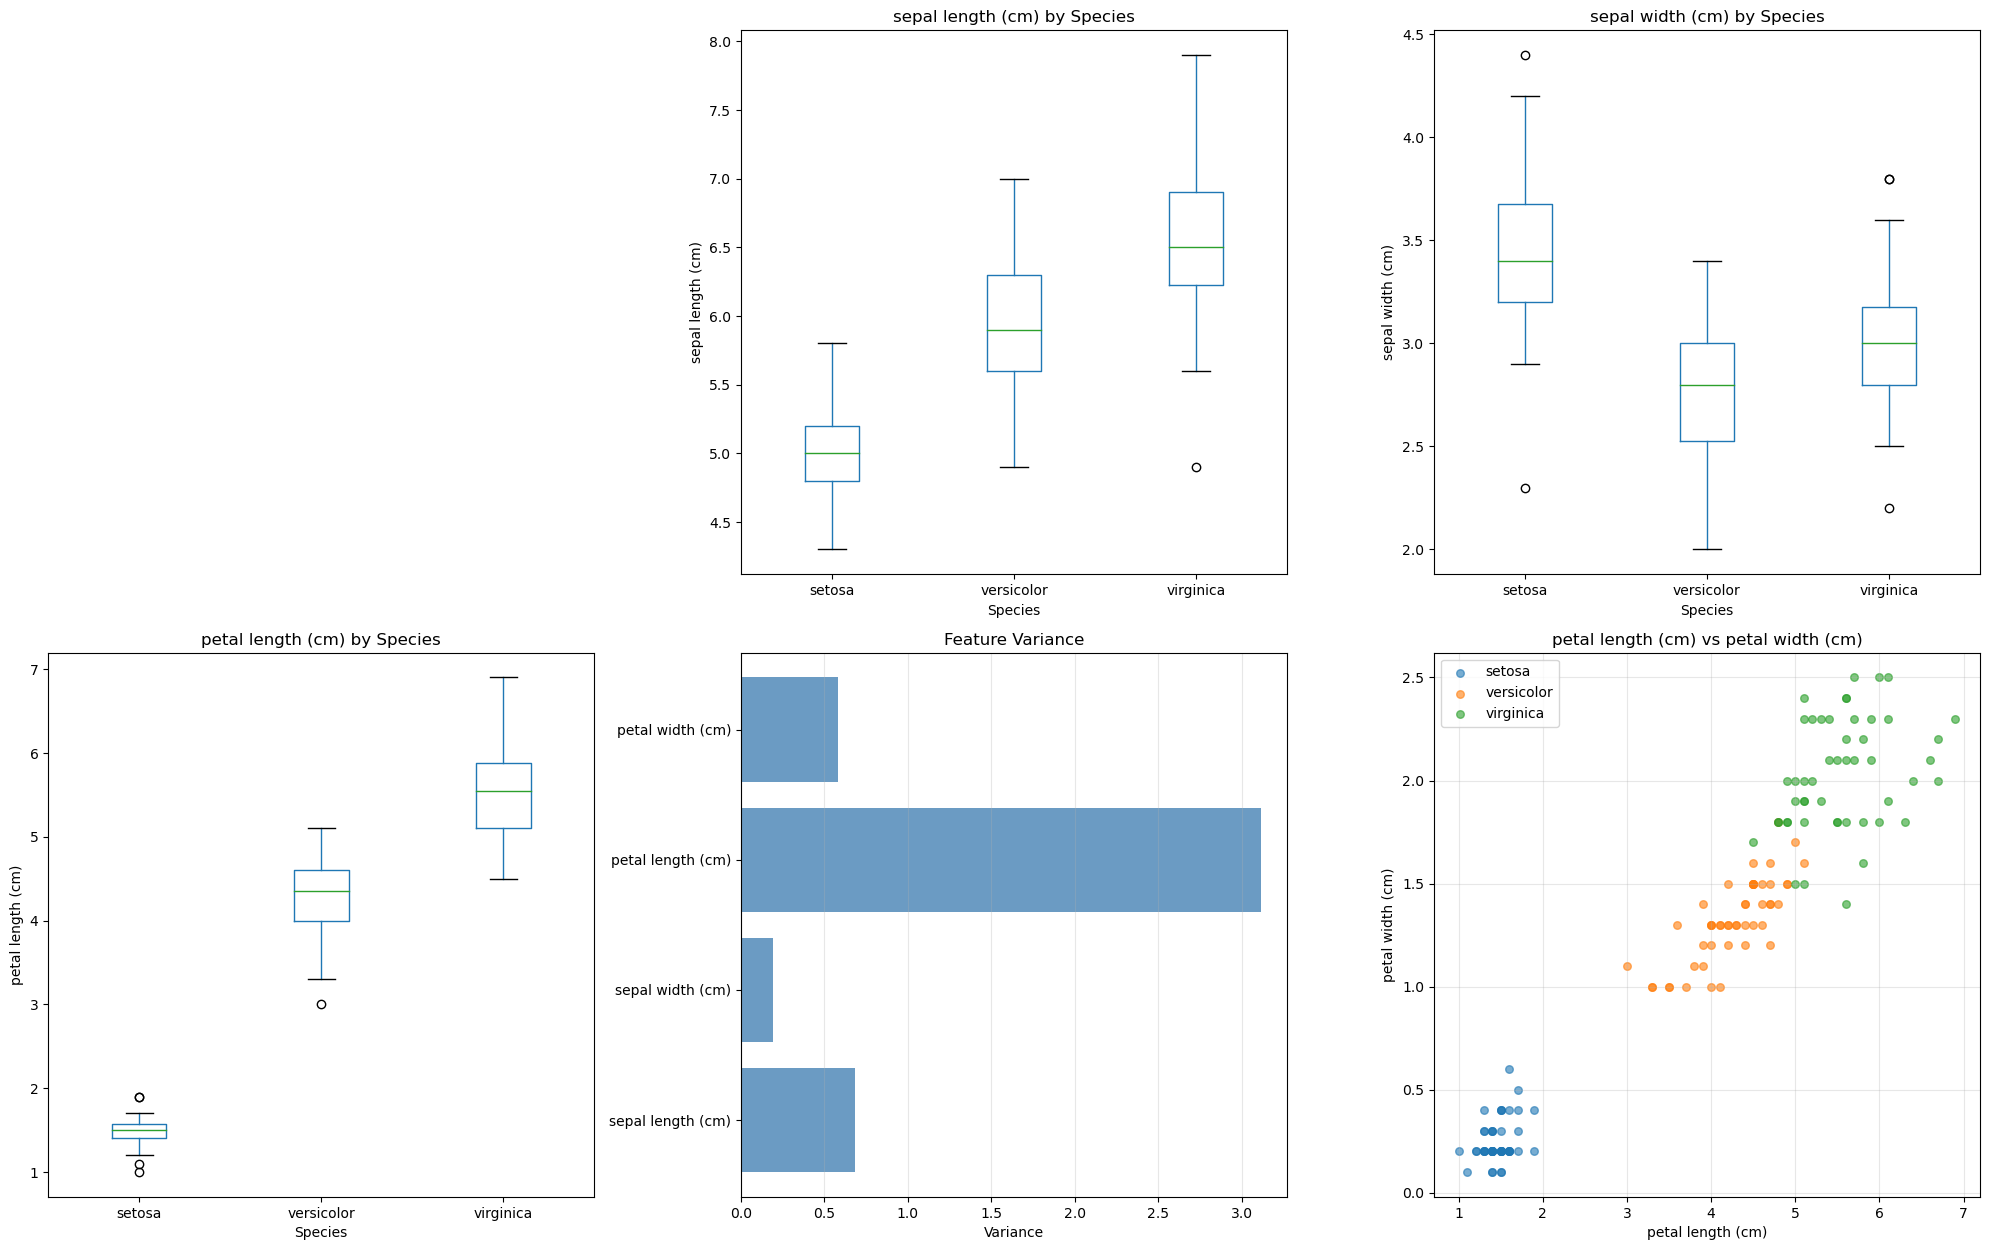

In [5]:

#  Box plots for features
fig = plt.figure(figsize=(20, 25))
for i, feature in enumerate(feature_names[:3], 8):
    ax = plt.subplot(4, 3, i)
    df.boxplot(column=feature, by='species', ax=ax, grid=False)
    ax.set_title(f'{feature} by Species')
    ax.set_xlabel('Species')
    ax.set_ylabel(feature)
    plt.suptitle('')  # Remove default title

#  Feature importance visualization (variance)
ax11 = plt.subplot(4, 3, 11)
feature_variance = df[feature_names].var()
ax11.barh(feature_names, feature_variance, alpha=0.8, color='steelblue')
ax11.set_xlabel('Variance')
ax11.set_title('Feature Variance')
ax11.grid(True, alpha=0.3, axis='x')

#  Class separability (PCA-like visualization)
ax12 = plt.subplot(4, 3, 12)
# Use first two features for visualization
for j, species in enumerate(target_names):
    ax12.scatter(df[df['species'] == species][feature_names[2]], 
                df[df['species'] == species][feature_names[3]], 
                alpha=0.6, label=species, s=30)
ax12.set_xlabel(feature_names[2])
ax12.set_ylabel(feature_names[3])
ax12.set_title(f'{feature_names[2]} vs {feature_names[3]}')
ax12.legend()
ax12.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.1.5 | </span><span style='color:#800000'>  Features Correlated - Outlier </span></b>

In [6]:
print(f"\n8. Feature Correlation Analysis:")
corr_with_target = {}
for feature in feature_names:
    # Calculate correlation with target (using numeric target)
    corr = df[feature].corr(df['target'])
    corr_with_target[feature] = abs(corr)
sorted_corr = sorted(corr_with_target.items(), key=lambda x: x[1], reverse=True)
print("   Features most correlated with target:")
for feature, corr_val in sorted_corr:
    print(f"   - {feature}: {corr_val:.3f}")

print(f"\n9. Outlier Detection (IQR method):")
outliers_summary = {}
for feature in feature_names:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    if IQR > 0:
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((df[feature] < lower_bound) | (df[feature] > upper_bound)).sum()
        outliers_summary[feature] = outliers
        if outliers > 0:
            print(f"   - {feature}: {outliers} outliers ({100*outliers/len(df):.1f}%)")
if sum(outliers_summary.values()) == 0:
    print("   ✅ No outliers detected")

print("\n✅ Iris EDA Complete!")
print("=" * 80)


8. Feature Correlation Analysis:
   Features most correlated with target:
   - petal width (cm): 0.957
   - petal length (cm): 0.949
   - sepal length (cm): 0.783
   - sepal width (cm): 0.427

9. Outlier Detection (IQR method):
   - sepal width (cm): 4 outliers (2.7%)

✅ Iris EDA Complete!


<a id="eda2"></a>
## <b><span style='color:#299617'>Step 2.2 | </span><span style='color:#299617'>EDA for  Wine Classification Dataset</span></b>
⬆️ [Tabel of Contents](#contents_tabel)

<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.2.1 | </span><span style='color:#800000'> Load dataset, Create DataFrame  </span></b>

In [7]:
print("=" * 80)

# Load dataset
from sklearn.datasets import load_wine
data = load_wine()
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_names

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['class'] = [target_names[i] for i in y]

print(f"\n1. Dataset Overview:")
print(f"   - Shape: {df.shape[0]} samples × {df.shape[1]} features (including target)")
print(f"   - Features: {len(feature_names)}")
print(f"   - Target variable: Wine Class (classification)")
print(f"   - Classes: {len(np.unique(y))} ({', '.join(target_names)})")

print(f"\n2. Feature Names:")
for i, name in enumerate(feature_names, 1):
    print(f"   {i}. {name}")

print(f"\n3. Basic Statistics:")
print(df[feature_names].describe().round(2))

print(f"\n4. Data Types:")
print(df.dtypes)

print(f"\n5. Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ No missing values found")
else:
    print(missing[missing > 0])

print(f"\n6. Class Distribution:")
unique_classes, counts = np.unique(y, return_counts=True)
for cls, count, name in zip(unique_classes, counts, target_names):
    print(f"   - Class {cls} ({name}): {count} samples ({100*count/len(y):.1f}%)")
print(f"   - Balanced: {'Yes' if max(counts) - min(counts) <= 3 else 'No'}")

print(f"\n7. Feature Statistics by Class:")
for i, name in enumerate(target_names):
    print(f"\n   Class {i} ({name}):")
    class_data = df[df['target'] == i][feature_names]
    print(f"      Mean range: [{class_data.mean().min():.2f}, {class_data.mean().max():.2f}]")
    print(f"      Std range:  [{class_data.std().min():.2f}, {class_data.std().max():.2f}]")




1. Dataset Overview:
   - Shape: 178 samples × 15 features (including target)
   - Features: 13
   - Target variable: Wine Class (classification)
   - Classes: 3 (class_0, class_1, class_2)

2. Feature Names:
   1. alcohol
   2. malic_acid
   3. ash
   4. alcalinity_of_ash
   5. magnesium
   6. total_phenols
   7. flavanoids
   8. nonflavanoid_phenols
   9. proanthocyanins
   10. color_intensity
   11. hue
   12. od280/od315_of_diluted_wines
   13. proline

3. Basic Statistics:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56      

<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.2.2 | </span><span style='color:#800000'>  Visualizations </span></b>

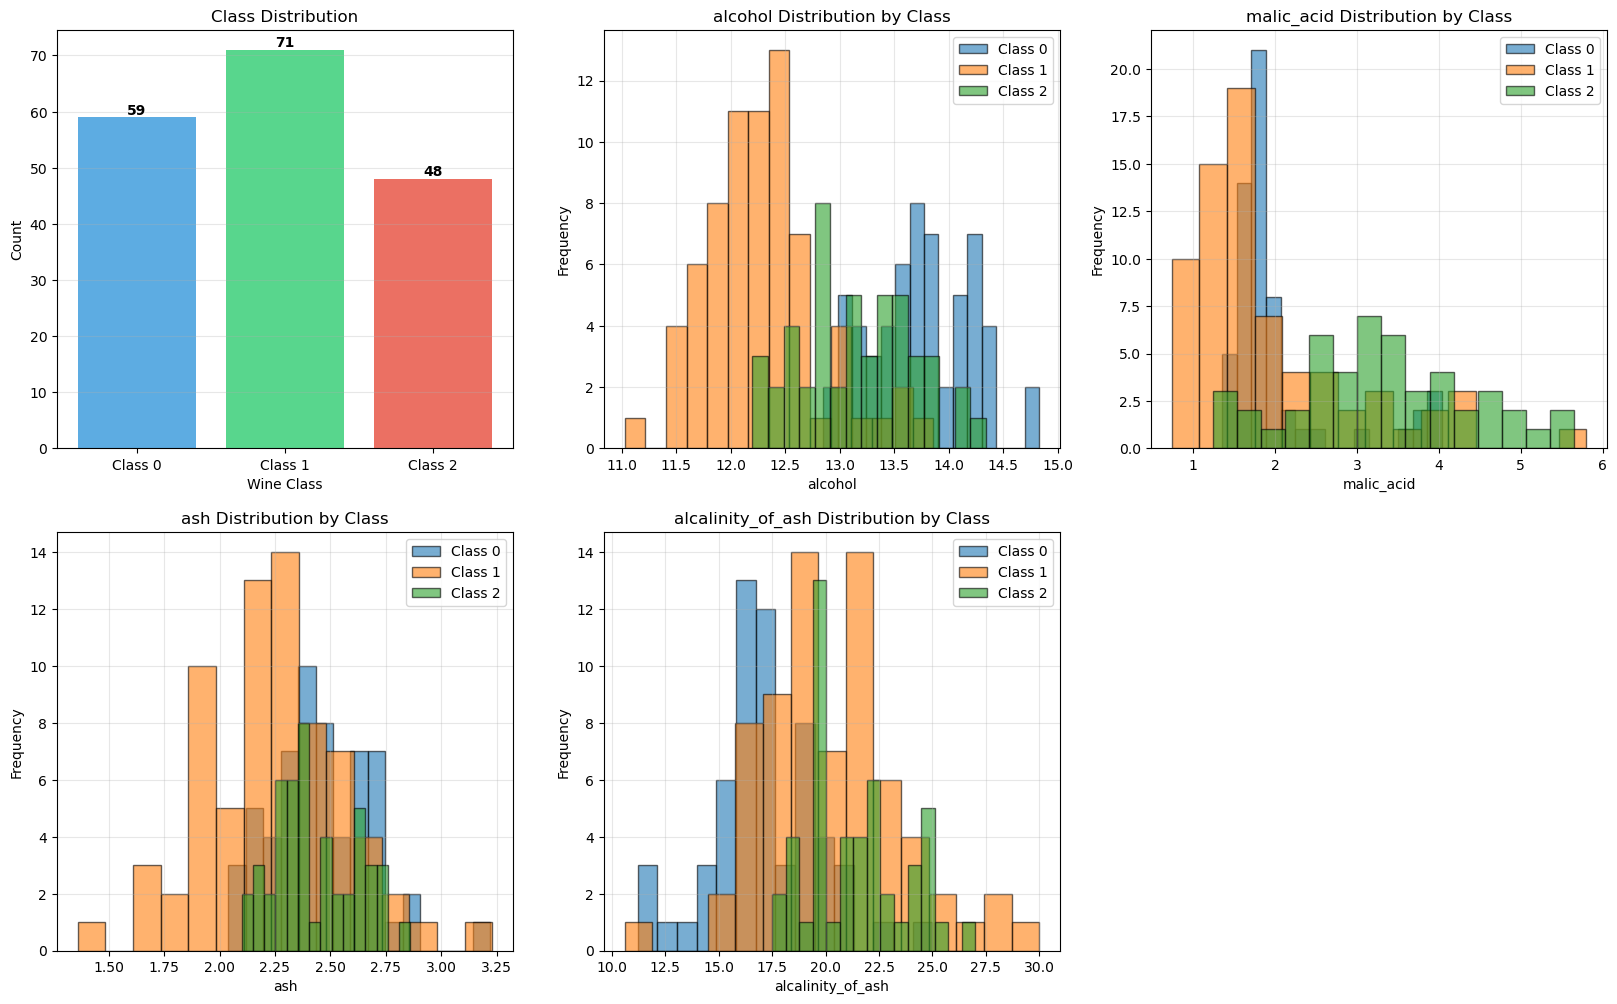

In [8]:
# Visualizations
fig = plt.figure(figsize=(20, 25))

# Class distribution
ax1 = plt.subplot(4, 3, 1)
class_counts = pd.Series(y).value_counts().sort_index()
bars = ax1.bar([f'Class {i}' for i in range(len(target_names))], class_counts.values, 
               alpha=0.8, color=['#3498db', '#2ecc71', '#e74c3c'])
ax1.set_xlabel('Wine Class')
ax1.set_ylabel('Count')
ax1.set_title('Class Distribution')
for bar, count in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{count}', ha='center', va='bottom', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 2-5 Key feature distributions by class
key_features = ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash']
for i, feature in enumerate(key_features[:4], 2):
    ax = plt.subplot(4, 3, i)
    for j, class_name in enumerate(target_names):
        ax.hist(df[df['class'] == class_name][feature], bins=15, alpha=0.6, 
                label=f'Class {j}', edgecolor='black')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{feature} Distribution by Class')
    ax.legend()
    ax.grid(True, alpha=0.3)



<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.2.3 | </span><span style='color:#800000'>  Feature distributions </span></b>

Text(0.5, 1.0, 'Feature Correlation Matrix (Top 8)')

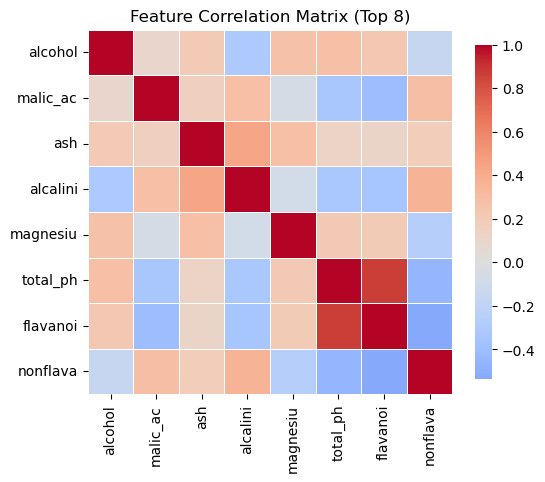

In [9]:
# 6. Correlation matrix (showing top correlations)
fig = plt.figure(figsize=(20, 25))
ax6 = plt.subplot(4, 3, 6)
corr_matrix = df[feature_names].corr()
# Select subset of features for readability
top_features = feature_names[:8]
sns.heatmap(df[top_features].corr(), annot=False, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax6,
            xticklabels=[f[:8] for f in top_features], 
            yticklabels=[f[:8] for f in top_features])
ax6.set_title('Feature Correlation Matrix (Top 8)')



<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.2.4 | </span><span style='color:#800000'>  Target vs Features </span></b>

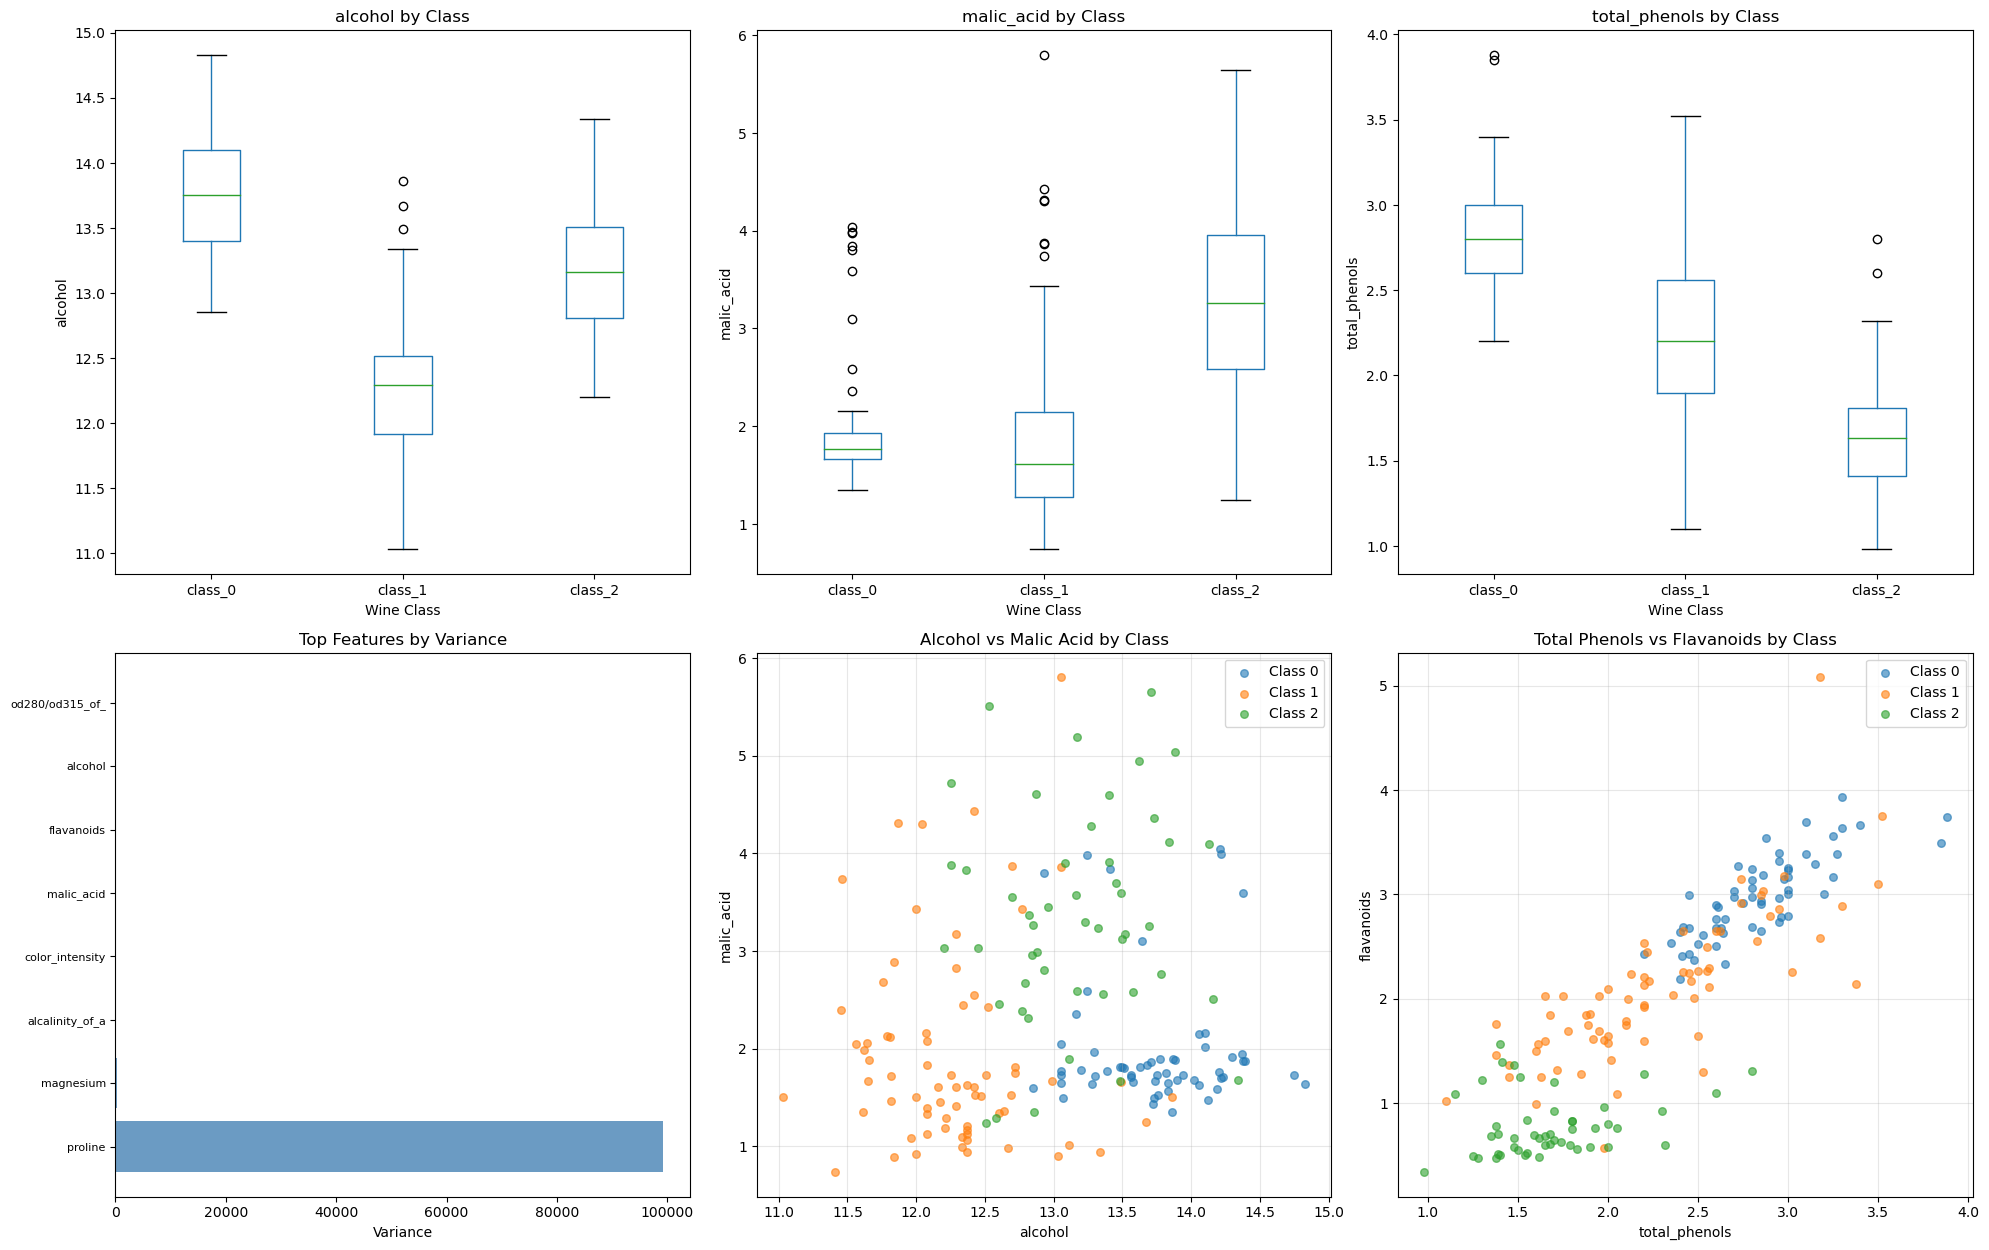

In [10]:
# 7-9. Box plots for key features
fig = plt.figure(figsize=(20, 25))
for i, feature in enumerate(['alcohol', 'malic_acid', 'total_phenols'], 7):
    ax = plt.subplot(4, 3, i)
    df.boxplot(column=feature, by='class', ax=ax, grid=False)
    ax.set_title(f'{feature} by Class')
    ax.set_xlabel('Wine Class')
    ax.set_ylabel(feature)
    plt.suptitle('')

# 10. Feature importance (variance)
ax10 = plt.subplot(4, 3, 10)
feature_variance = df[feature_names].var().sort_values(ascending=False)
top_var_features = feature_variance.head(8)
ax10.barh(range(len(top_var_features)), top_var_features.values, alpha=0.8, color='steelblue')
ax10.set_yticks(range(len(top_var_features)))
ax10.set_yticklabels([f[:15] for f in top_var_features.index], fontsize=8)
ax10.set_xlabel('Variance')
ax10.set_title('Top Features by Variance')

# 11. Scatter plot: alcohol vs malic_acid
ax11 = plt.subplot(4, 3, 11)
for j, class_name in enumerate(target_names):
    ax11.scatter(df[df['class'] == class_name]['alcohol'], 
                df[df['class'] == class_name]['malic_acid'], 
                alpha=0.6, label=f'Class {j}', s=30)
ax11.set_xlabel('alcohol')
ax11.set_ylabel('malic_acid')
ax11.set_title('Alcohol vs Malic Acid by Class')
ax11.legend()
ax11.grid(True, alpha=0.3)

# 12. Class separability (using two features)
ax12 = plt.subplot(4, 3, 12)
for j, class_name in enumerate(target_names):
    ax12.scatter(df[df['class'] == class_name]['total_phenols'], 
                df[df['class'] == class_name]['flavanoids'], 
                alpha=0.6, label=f'Class {j}', s=30)
ax12.set_xlabel('total_phenols')
ax12.set_ylabel('flavanoids')
ax12.set_title('Total Phenols vs Flavanoids by Class')
ax12.legend()
ax12.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.2.5 | </span><span style='color:#800000'>  Features Correlated </span></b>

In [11]:
print(f"\n8. Feature Correlation with Target:")
# Calculate mean feature value per class to understand class differences
print("   Mean feature values by class:")
for feature in feature_names[:5]:  # Show first 5
    means_by_class = [df[df['target'] == i][feature].mean() for i in range(len(target_names))]
    print(f"   - {feature}: {[f'{m:.2f}' for m in means_by_class]}")

print("\n✅ Wine Classification EDA Complete!")
print("=" * 80)



8. Feature Correlation with Target:
   Mean feature values by class:
   - alcohol: ['13.74', '12.28', '13.15']
   - malic_acid: ['2.01', '1.93', '3.33']
   - ash: ['2.46', '2.24', '2.44']
   - alcalinity_of_ash: ['17.04', '20.24', '21.42']
   - magnesium: ['106.34', '94.55', '99.31']

✅ Wine Classification EDA Complete!


<a id="eda3"></a>
## <b><span style='color:#299617'>Step 2.3 | </span><span style='color:#299617'>EDA for Breast Cancer Dataset</span></b>
⬆️ [Tabel of Contents](#contents_tabel)

<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.3.1 | </span><span style='color:#800000'> Load dataset, Create DataFrame  </span></b>

In [12]:
print("=" * 80)

# Load dataset
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_names

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['diagnosis'] = [target_names[i] for i in y]

print(f"\n1. Dataset Overview:")
print(f"   - Shape: {df.shape[0]} samples × {df.shape[1]} features (including target)")
print(f"   - Features: {len(feature_names)}")
print(f"   - Target variable: Diagnosis (binary classification)")
print(f"   - Classes: {len(np.unique(y))} ({', '.join(target_names)})")
print(f"   - Note: Medical diagnosis dataset (malignant vs benign)")

print(f"\n2. Feature Categories:")
# Group features by their type
feature_groups = {}
for feature in feature_names:
    base_name = feature.split('_')[0] if '_' in feature else feature
    if base_name not in feature_groups:
        feature_groups[base_name] = []
    feature_groups[base_name].append(feature)

print(f"   Feature groups: {len(feature_groups)}")
for group, features in list(feature_groups.items())[:5]:
    print(f"   - {group}: {len(features)} features")

print(f"\n3. Basic Statistics (sample of features):")
print(df[feature_names[:5]].describe().round(2))

print(f"\n4. Data Types:")
print(df.dtypes.value_counts())

print(f"\n5. Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ No missing values found")
else:
    print(missing[missing > 0])

print(f"\n6. Class Distribution:")
unique_classes, counts = np.unique(y, return_counts=True)
for cls, count, name in zip(unique_classes, counts, target_names):
    print(f"   - {name} (Class {cls}): {count} samples ({100*count/len(y):.1f}%)")
imbalance_ratio = max(counts) / min(counts)
print(f"   - Class imbalance ratio: {imbalance_ratio:.2f}")
print(f"   - Balanced: {'Yes' if imbalance_ratio < 1.5 else 'No'}")

print(f"\n7. Feature Statistics by Class:")
for i, name in enumerate(target_names):
    print(f"\n   {name}:")
    class_data = df[df['target'] == i][feature_names]
    print(f"      Mean range: [{class_data.mean().min():.2f}, {class_data.mean().max():.2f}]")
    print(f"      Std range:  [{class_data.std().min():.2f}, {class_data.std().max():.2f}]")




1. Dataset Overview:
   - Shape: 569 samples × 32 features (including target)
   - Features: 30
   - Target variable: Diagnosis (binary classification)
   - Classes: 2 (malignant, benign)
   - Note: Medical diagnosis dataset (malignant vs benign)

2. Feature Categories:
   Feature groups: 30
   - mean radius: 1 features
   - mean texture: 1 features
   - mean perimeter: 1 features
   - mean area: 1 features
   - mean smoothness: 1 features

3. Basic Statistics (sample of features):
       mean radius  mean texture  mean perimeter  mean area  mean smoothness
count       569.00        569.00          569.00     569.00           569.00
mean         14.13         19.29           91.97     654.89             0.10
std           3.52          4.30           24.30     351.91             0.01
min           6.98          9.71           43.79     143.50             0.05
25%          11.70         16.17           75.17     420.30             0.09
50%          13.37         18.84           86.24  

<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.3.2 | </span><span style='color:#800000'>  Visualizations </span></b>

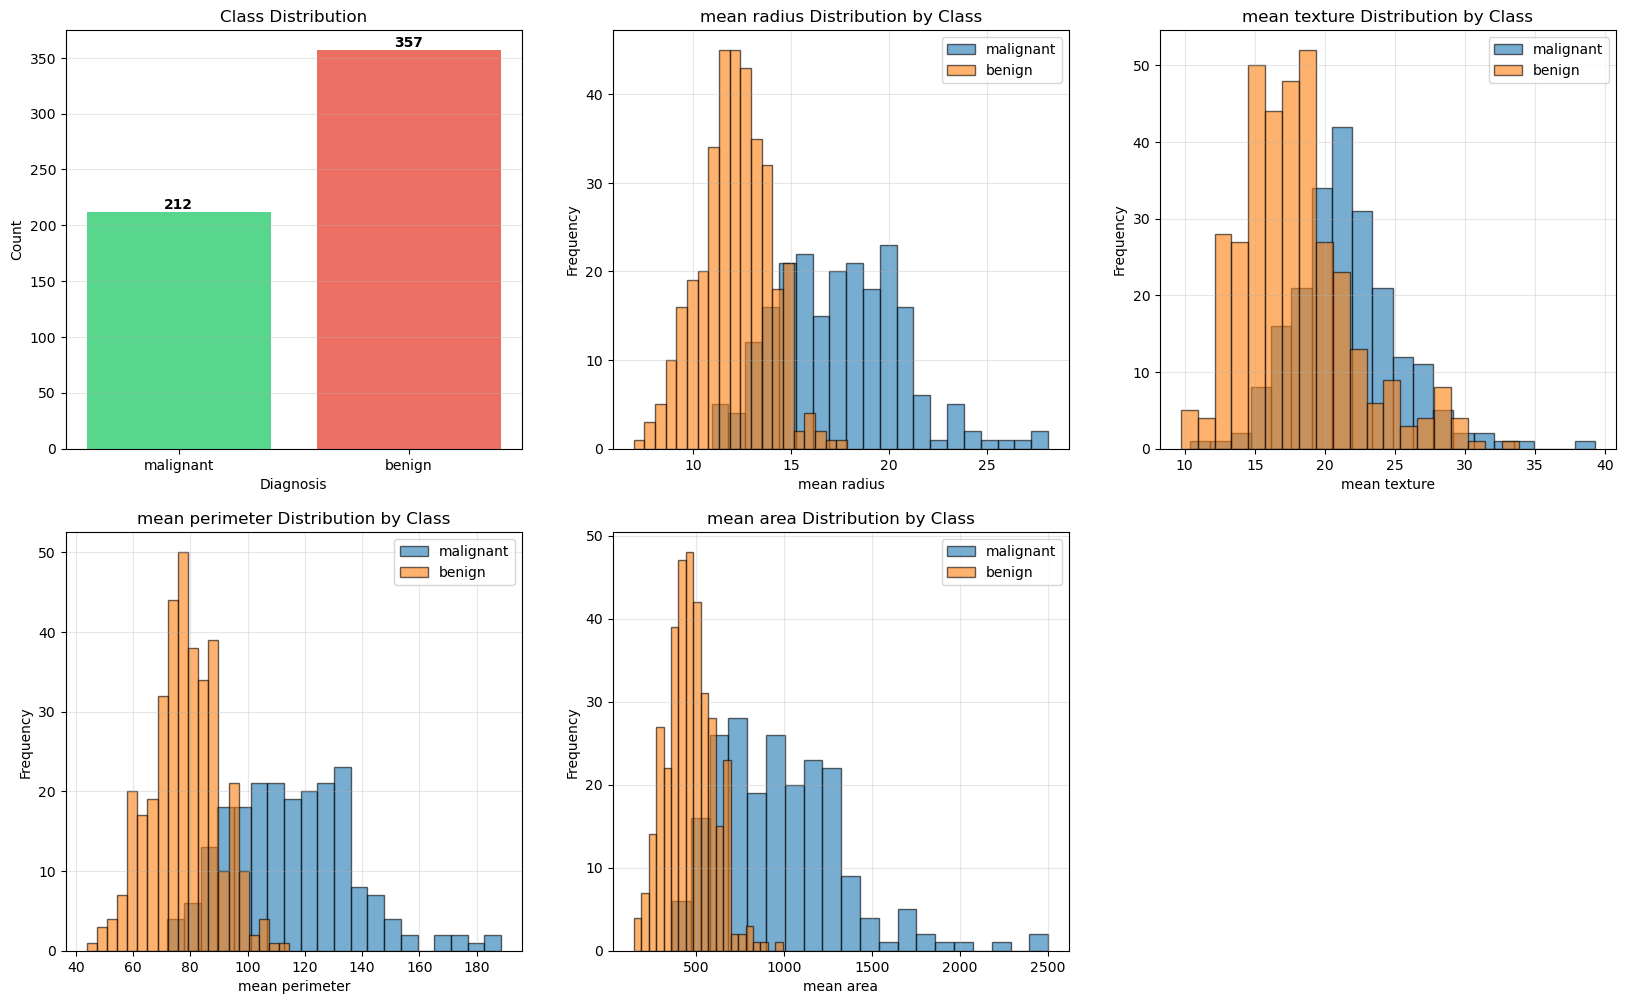

In [13]:
# Visualizations
fig = plt.figure(figsize=(20, 25))

# 1. Class distribution
ax1 = plt.subplot(4, 3, 1)
class_counts = pd.Series(y).value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']  # Green for benign, red for malignant
bars = ax1.bar(target_names, class_counts.values, alpha=0.8, color=colors)
ax1.set_xlabel('Diagnosis')
ax1.set_ylabel('Count')
ax1.set_title('Class Distribution')
for bar, count in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{count}', ha='center', va='bottom', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 2-5. Key feature distributions (mean radius, mean texture, mean perimeter, mean area)
key_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
for i, feature in enumerate(key_features[:4], 2):
    ax = plt.subplot(4, 3, i)
    for j, name in enumerate(target_names):
        ax.hist(df[df['diagnosis'] == name][feature], bins=20, alpha=0.6, 
                label=name, edgecolor='black')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{feature} Distribution by Class')
    ax.legend()
    ax.grid(True, alpha=0.3)



<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.3.3 | </span><span style='color:#800000'>  Feature distributions </span></b>

Text(0.5, 1.0, 'Feature Correlation Matrix (Sample)')

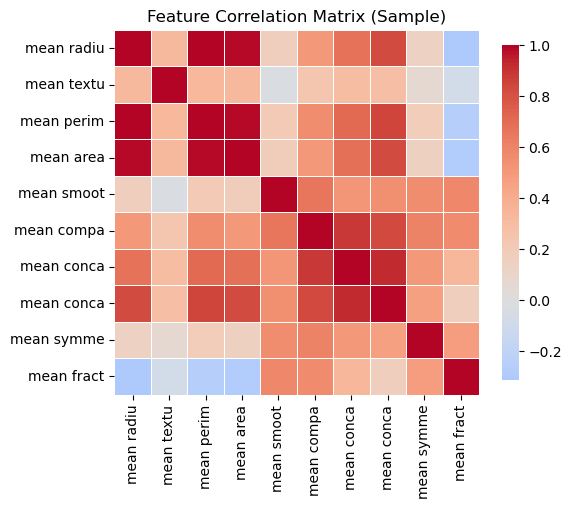

In [14]:
# 6. Correlation matrix (sample of features)
fig = plt.figure(figsize=(20, 25))
ax6 = plt.subplot(4, 3, 6)
sample_features = feature_names[:10]  # First 10 features
corr_matrix = df[sample_features].corr()
sns.heatmap(corr_matrix, annot=False, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax6,
            xticklabels=[f[:10] for f in sample_features], 
            yticklabels=[f[:10] for f in sample_features])
ax6.set_title('Feature Correlation Matrix (Sample)')




<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.3.4 | </span><span style='color:#800000'>  Target vs Features </span></b>

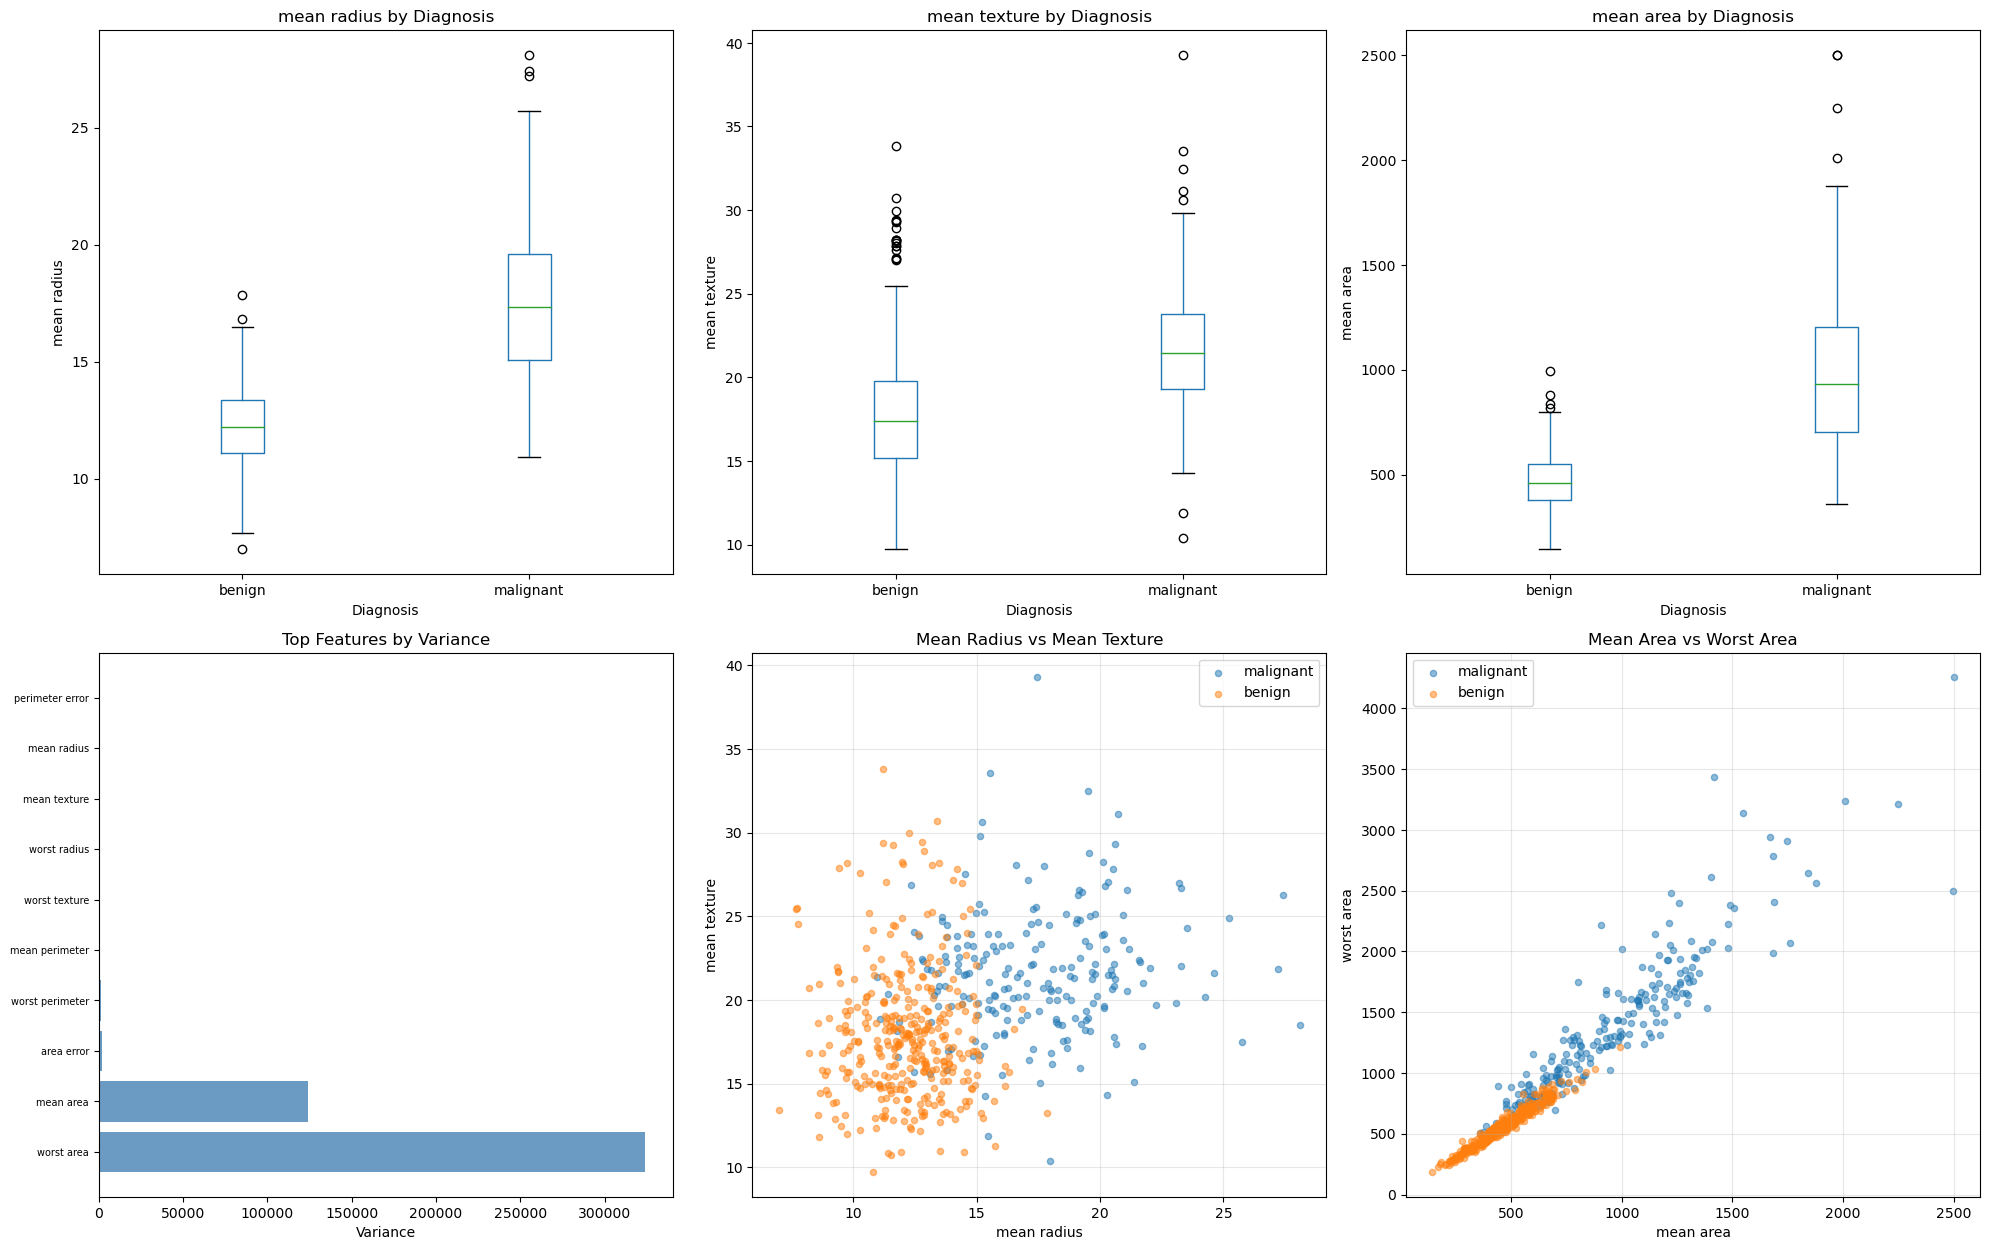

In [15]:
# 7-9. Box plots for key features
fig = plt.figure(figsize=(20, 25))
for i, feature in enumerate(['mean radius', 'mean texture', 'mean area'], 7):
    ax = plt.subplot(4, 3, i)
    df.boxplot(column=feature, by='diagnosis', ax=ax, grid=False)
    ax.set_title(f'{feature} by Diagnosis')
    ax.set_xlabel('Diagnosis')
    ax.set_ylabel(feature)
    plt.suptitle('')

# 10. Feature importance (variance)
ax10 = plt.subplot(4, 3, 10)
feature_variance = df[feature_names].var().sort_values(ascending=False)
top_var_features = feature_variance.head(10)
ax10.barh(range(len(top_var_features)), top_var_features.values, alpha=0.8, color='steelblue')
ax10.set_yticks(range(len(top_var_features)))
ax10.set_yticklabels([f[:20] for f in top_var_features.index], fontsize=7)
ax10.set_xlabel('Variance')
ax10.set_title('Top Features by Variance')

# 11. Scatter plot: mean radius vs mean texture
ax11 = plt.subplot(4, 3, 11)
for j, name in enumerate(target_names):
    ax11.scatter(df[df['diagnosis'] == name]['mean radius'], 
                df[df['diagnosis'] == name]['mean texture'], 
                alpha=0.5, label=name, s=20)
ax11.set_xlabel('mean radius')
ax11.set_ylabel('mean texture')
ax11.set_title('Mean Radius vs Mean Texture')
ax11.legend()
ax11.grid(True, alpha=0.3)

# 12. Feature separability (mean area vs worst area)
ax12 = plt.subplot(4, 3, 12)
for j, name in enumerate(target_names):
    ax12.scatter(df[df['diagnosis'] == name]['mean area'], 
                df[df['diagnosis'] == name]['worst area'], 
                alpha=0.5, label=name, s=20)
ax12.set_xlabel('mean area')
ax12.set_ylabel('worst area')
ax12.set_title('Mean Area vs Worst Area')
ax12.legend()
ax12.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.2.5 | </span><span style='color:#800000'>  Features Correlated </span></b>

In [16]:

print(f"\n8. Top Discriminative Features:")
# Calculate feature difference between classes
feature_differences = {}
for feature in feature_names:
    benign_mean = df[df['target'] == 0][feature].mean()
    malignant_mean = df[df['target'] == 1][feature].mean()
    feature_differences[feature] = abs(benign_mean - malignant_mean)

top_diff = sorted(feature_differences.items(), key=lambda x: x[1], reverse=True)[:10]
print("   Features with largest mean difference between classes:")
for feature, diff in top_diff:
    print(f"   - {feature}: {diff:.2f}")

print("\n✅ Breast Cancer EDA Complete!")
print("=" * 80)


8. Top Discriminative Features:
   Features with largest mean difference between classes:
   - worst area: 863.39
   - mean area: 515.59
   - worst perimeter: 54.36
   - area error: 51.54
   - mean perimeter: 37.29
   - worst radius: 7.76
   - worst texture: 5.80
   - mean radius: 5.32
   - mean texture: 3.69
   - perimeter error: 2.32

✅ Breast Cancer EDA Complete!


<a id="eda4"></a>
## <b><span style='color:#299617'>Step 2.4 | </span><span style='color:#299617'>EDA for Credit Default Dataset</span></b>
⬆️ [Tabel of Contents](#contents_tabel)

<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.4.1 | </span><span style='color:#800000'> Load dataset, Create DataFrame  </span></b>

In [17]:
print("=" * 80)

# Generate synthetic credit default data (matching project structure)
np.random.seed(42)
n_samples = 1000
n_features = 10

# Create features with realistic relationships
X = np.random.randn(n_samples, n_features)
# Create binary target with logistic relationship
prob = 1 / (1 + np.exp(-(X[:, 0] * 0.5 + X[:, 1] * 0.3 + np.random.randn(n_samples) * 0.1)))
y = (prob > 0.5).astype(int)

feature_names = [f'feature_{i+1}' for i in range(n_features)]

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['default'] = ['Yes' if i == 1 else 'No' for i in y]

print(f"\n1. Dataset Overview:")
print(f"   - Shape: {df.shape[0]} samples × {df.shape[1]} features (including target)")
print(f"   - Features: {len(feature_names)}")
print(f"   - Target variable: Credit Default (binary classification)")
print(f"   - Classes: 2 (No Default: 0, Default: 1)")
print(f"   - Note: Synthetic dataset for classification analysis")
print(f"   - True model: Logistic relationship (feature_1, feature_2 have strongest impact)")

print(f"\n2. Feature Names:")
for i, name in enumerate(feature_names, 1):
    print(f"   {i}. {name}")

print(f"\n3. Basic Statistics:")
print(df[feature_names].describe().round(2))

print(f"\n4. Data Types:")
print(df.dtypes.value_counts())

print(f"\n5. Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ No missing values found")
else:
    print(missing[missing > 0])

print(f"\n6. Class Distribution:")
unique_classes, counts = np.unique(y, return_counts=True)
class_labels = ['No Default', 'Default']
for cls, count, label in zip(unique_classes, counts, class_labels):
    print(f"   - {label} (Class {cls}): {count} samples ({100*count/len(y):.1f}%)")
imbalance_ratio = max(counts) / min(counts)
print(f"   - Class imbalance ratio: {imbalance_ratio:.2f}")
print(f"   - Balanced: {'Yes' if imbalance_ratio < 1.5 else 'No'}")

print(f"\n7. Feature Statistics by Class:")
for i, label in enumerate(class_labels):
    print(f"\n   {label}:")
    class_data = df[df['target'] == i][feature_names]
    print(f"      Mean range: [{class_data.mean().min():.2f}, {class_data.mean().max():.2f}]")
    print(f"      Std range:  [{class_data.std().min():.2f}, {class_data.std().max():.2f}]")




1. Dataset Overview:
   - Shape: 1000 samples × 12 features (including target)
   - Features: 10
   - Target variable: Credit Default (binary classification)
   - Classes: 2 (No Default: 0, Default: 1)
   - Note: Synthetic dataset for classification analysis
   - True model: Logistic relationship (feature_1, feature_2 have strongest impact)

2. Feature Names:
   1. feature_1
   2. feature_2
   3. feature_3
   4. feature_4
   5. feature_5
   6. feature_6
   7. feature_7
   8. feature_8
   9. feature_9
   10. feature_10

3. Basic Statistics:
       feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
count    1000.00    1000.00    1000.00    1000.00    1000.00    1000.00   
mean        0.01       0.03      -0.02      -0.04       0.01      -0.03   
std         1.01       1.02       0.98       0.98       1.01       1.04   
min        -3.92      -3.69      -3.24      -2.94      -3.14      -3.17   
25%        -0.62      -0.63      -0.70      -0.75      -0.65      -0.75   
50%

<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.4.2 | </span><span style='color:#800000'>  Visualizations </span></b>

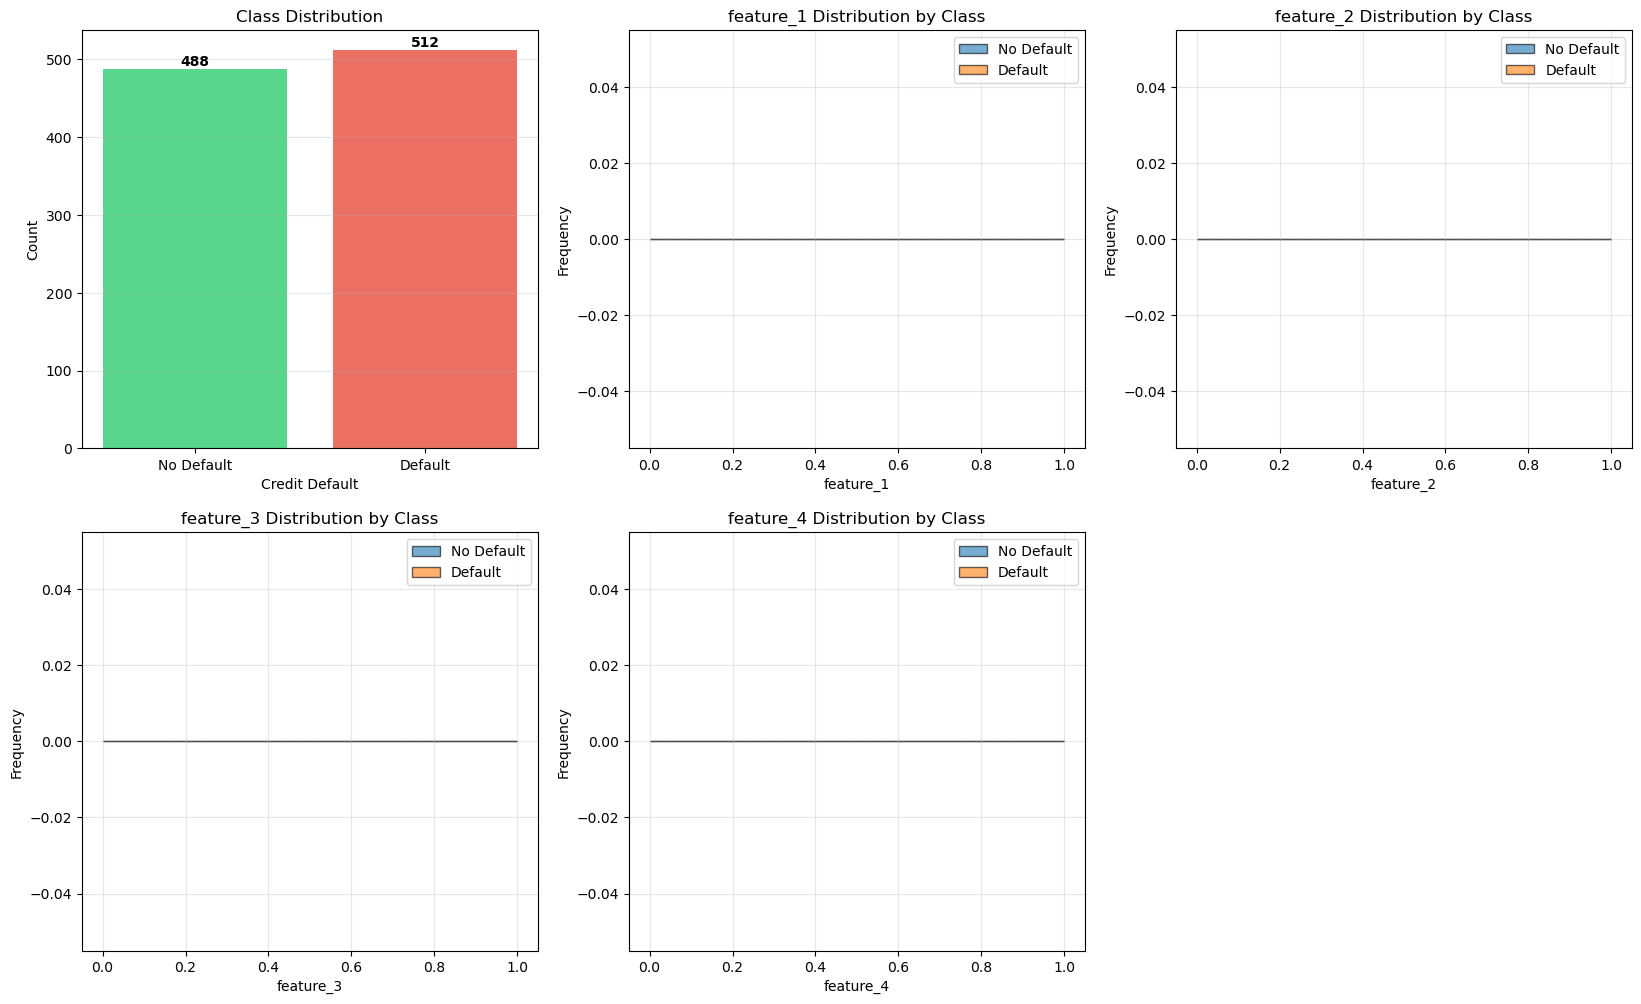

In [18]:
# Visualizations
fig = plt.figure(figsize=(20, 25))

# 1. Class distribution
ax1 = plt.subplot(4, 3, 1)
class_counts = pd.Series(y).value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']  # Green for no default, red for default
bars = ax1.bar(class_labels, class_counts.values, alpha=0.8, color=colors)
ax1.set_xlabel('Credit Default')
ax1.set_ylabel('Count')
ax1.set_title('Class Distribution')
for bar, count in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{count}', ha='center', va='bottom', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 2-5. Feature distributions by class (top 4 features)
top_features = feature_names[:4]
for i, feature in enumerate(top_features, 2):
    ax = plt.subplot(4, 3, i)
    for j, label in enumerate(class_labels):
        ax.hist(df[df['default'] == label][feature], bins=25, alpha=0.6, 
                label=label, edgecolor='black')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{feature} Distribution by Class')
    ax.legend()
    ax.grid(True, alpha=0.3)



<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.4.3 | </span><span style='color:#800000'>   Correlation matrix </span></b>

Text(0.5, 1.0, 'Feature Correlation Matrix')

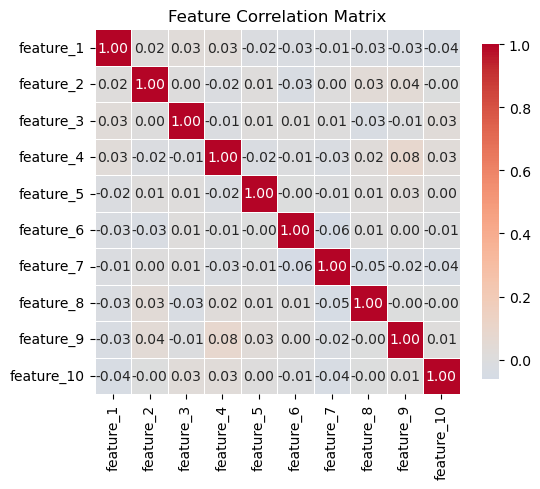

In [19]:
# 6. Correlation matrix
fig = plt.figure(figsize=(20, 25))
ax6 = plt.subplot(4, 3, 6)
corr_matrix = df[feature_names].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax6)
ax6.set_title('Feature Correlation Matrix')



<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.4.4 | </span><span style='color:#800000'>  Target vs Features </span></b>

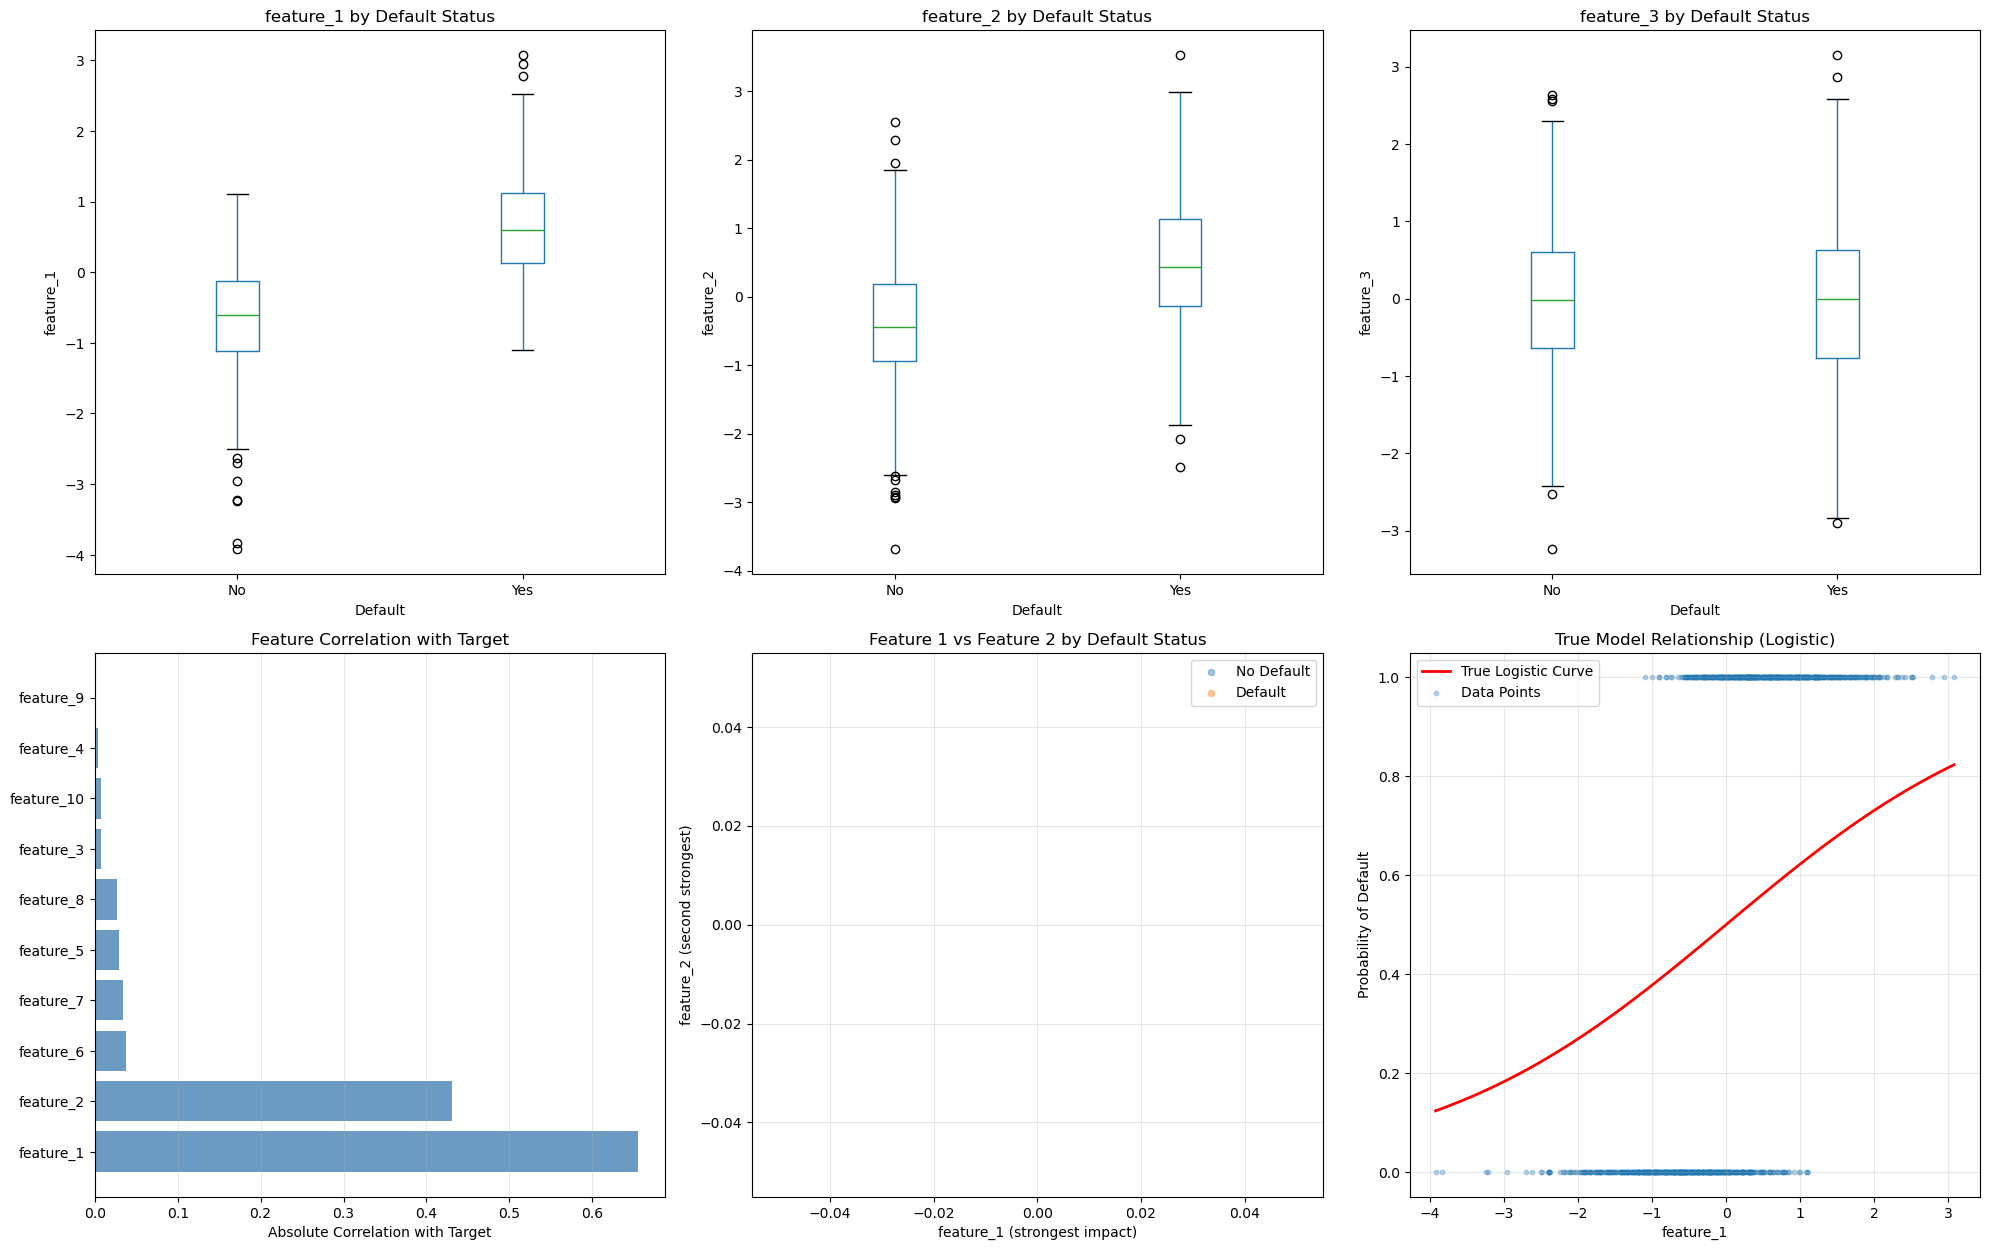

In [20]:
# 7-9. Box plots for key features
fig = plt.figure(figsize=(20, 25))
for i, feature in enumerate(['feature_1', 'feature_2', 'feature_3'], 7):
    ax = plt.subplot(4, 3, i)
    df.boxplot(column=feature, by='default', ax=ax, grid=False)
    ax.set_title(f'{feature} by Default Status')
    ax.set_xlabel('Default')
    ax.set_ylabel(feature)
    plt.suptitle('')

# 10. Feature importance (correlation with target)
ax10 = plt.subplot(4, 3, 10)
feature_corr = {}
for feature in feature_names:
    corr = abs(df[feature].corr(df['target']))
    feature_corr[feature] = corr
sorted_corr = sorted(feature_corr.items(), key=lambda x: x[1], reverse=True)
features_sorted = [f[0] for f in sorted_corr]
corr_values = [f[1] for f in sorted_corr]
ax10.barh(features_sorted, corr_values, alpha=0.8, color='steelblue')
ax10.set_xlabel('Absolute Correlation with Target')
ax10.set_title('Feature Correlation with Target')
ax10.grid(True, alpha=0.3, axis='x')

# 11. Scatter plot: feature_1 vs feature_2 (most important)
ax11 = plt.subplot(4, 3, 11)
for j, label in enumerate(class_labels):
    ax11.scatter(df[df['default'] == label]['feature_1'], 
                df[df['default'] == label]['feature_2'], 
                alpha=0.4, label=label, s=20)
ax11.set_xlabel('feature_1 (strongest impact)')
ax11.set_ylabel('feature_2 (second strongest)')
ax11.set_title('Feature 1 vs Feature 2 by Default Status')
ax11.legend()
ax11.grid(True, alpha=0.3)

# 12. True model relationship visualization
ax12 = plt.subplot(4, 3, 12)
# Show the logistic relationship
x_range = np.linspace(df['feature_1'].min(), df['feature_1'].max(), 100)
logistic_curve = 1 / (1 + np.exp(-(x_range * 0.5)))
ax12.plot(x_range, logistic_curve, 'r-', linewidth=2, label='True Logistic Curve')
ax12.scatter(df['feature_1'], df['target'], alpha=0.3, s=10, label='Data Points')
ax12.set_xlabel('feature_1')
ax12.set_ylabel('Probability of Default')
ax12.set_title('True Model Relationship (Logistic)')
ax12.legend()
ax12.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



<a id="libraries"></a>
### <b><span style='color:#800000'>Step 2.4.5 | </span><span style='color:#800000'>  Features Correlated - Outlier </span></b>

In [21]:
print(f"\n8. Feature Correlation with Target:")
print("   Features most correlated with credit default:")
for feature, corr_val in sorted_corr[:5]:
    print(f"   - {feature}: {corr_val:.3f}")

print(f"\n9. True Model Information:")
print(f"   - True coefficients: feature_1=0.5, feature_2=0.3, others=0")
print(f"   - Expected correlations: feature_1 > feature_2 > others")
print(f"   - Model type: Logistic regression (binary classification)")

print(f"\n10. Outlier Detection (IQR method):")
outliers_summary = {}
for feature in feature_names:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    if IQR > 0:
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((df[feature] < lower_bound) | (df[feature] > upper_bound)).sum()
        outliers_summary[feature] = outliers
        if outliers > 0:
            print(f"   - {feature}: {outliers} outliers ({100*outliers/len(df):.1f}%)")
if sum(outliers_summary.values()) == 0:
    print("   ✅ No outliers detected (synthetic normal distribution)")

print("\n✅ Credit Default EDA Complete!")
print("=" * 80)



8. Feature Correlation with Target:
   Features most correlated with credit default:
   - feature_1: 0.655
   - feature_2: 0.431
   - feature_6: 0.038
   - feature_7: 0.034
   - feature_5: 0.029

9. True Model Information:
   - True coefficients: feature_1=0.5, feature_2=0.3, others=0
   - Expected correlations: feature_1 > feature_2 > others
   - Model type: Logistic regression (binary classification)

10. Outlier Detection (IQR method):
   - feature_1: 10 outliers (1.0%)
   - feature_2: 13 outliers (1.3%)
   - feature_3: 6 outliers (0.6%)
   - feature_4: 4 outliers (0.4%)
   - feature_5: 7 outliers (0.7%)
   - feature_6: 7 outliers (0.7%)
   - feature_7: 5 outliers (0.5%)
   - feature_8: 10 outliers (1.0%)
   - feature_9: 15 outliers (1.5%)
   - feature_10: 6 outliers (0.6%)

✅ Credit Default EDA Complete!


<a id="DP"></a>
# <b><span style='color:#09ba80'>Step 3 | </span><span style='color:#34e3ae'> Data Preprocessing </span></b>
⬆️ [Tabel of Contents](#contents_tabel)

<a id="DP1"></a>
## <b><span style='color:#299617'>Step 3.1 | </span><span style='color:#299617'>🔧 Data Preprocessing for Iris Dataset</span></b>
⬆️ [Tabel of Contents](#contents_tabel)

In [22]:

print("=" * 80)

# Load dataset
data = load_iris()
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"\n1. Initial Data Overview:")
print(f"   - Shape: {X.shape[0]} samples × {X.shape[1]} features")
print(f"   - Classes: {len(np.unique(y))} ({', '.join(target_names)})")
print(f"   - Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

# Create DataFrame for preprocessing
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"\n2. Missing Values Check:")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("   ✅ No missing values found")
else:
    print(f"   Found missing values:")
    print(missing_values[missing_values > 0])
    df = df.fillna(df.mean())

print(f"\n3. Infinite Values Check:")
inf_values = np.isinf(df.select_dtypes(include=[np.number])).sum()
if inf_values.sum() == 0:
    print("   ✅ No infinite values found")
else:
    print(f"   Found infinite values:")
    print(inf_values[inf_values > 0])
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(df.mean())

print(f"\n4. Outlier Detection and Handling (IQR method):")
outliers_count = 0
for col in feature_names:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR > 0:
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        if outliers > 0:
            outliers_count += outliers
            df[col] = np.clip(df[col], lower_bound, upper_bound)
if outliers_count > 0:
    print(f"   ✅ Capped {outliers_count} outliers across all features")
else:
    print("   ✅ No outliers detected")

print(f"\n5. Multicollinearity Check:")
corr_matrix = df[feature_names].corr().abs()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.8:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))
if high_corr_pairs:
    print(f"   ⚠️  Found {len(high_corr_pairs)} highly correlated feature pairs (>0.8):")
    for pair in high_corr_pairs[:3]:
        print(f"      {pair[0]} - {pair[1]}: {pair[2]:.3f}")
else:
    print("   ✅ No high multicollinearity detected")

# Extract processed data
X_processed = df[feature_names].values
y_processed = df['target'].values

print(f"\n6. Train-Test Split:")
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42, stratify=y_processed
)
print(f"   - Training set: {X_train.shape[0]} samples")
print(f"   - Test set: {X_test.shape[0]} samples")
print(f"   - Split ratio: 80/20 (stratified)")

print(f"\n7. Feature Scaling:")
scaler_standard = StandardScaler()
X_train_scaled_std = scaler_standard.fit_transform(X_train)
X_test_scaled_std = scaler_standard.transform(X_test)

scaler_robust = RobustScaler()
X_train_scaled_rob = scaler_robust.fit_transform(X_train)
X_test_scaled_rob = scaler_robust.transform(X_test)

print(f"   - StandardScaler: Mean ≈ 0, Std ≈ 1")
print(f"     Training mean range: [{X_train_scaled_std.mean(axis=0).min():.4f}, {X_train_scaled_std.mean(axis=0).max():.4f}]")
print(f"     Training std range: [{X_train_scaled_std.std(axis=0).min():.4f}, {X_train_scaled_std.std(axis=0).max():.4f}]")
print(f"   - RobustScaler: Median-based scaling")
print(f"     Training median range: [{np.median(X_train_scaled_rob, axis=0).min():.4f}, {np.median(X_train_scaled_rob, axis=0).max():.4f}]")

print(f"\n8. Class Distribution Check (after split):")
print(f"   Training set:")
for cls in np.unique(y_train):
    count = np.sum(y_train == cls)
    print(f"      Class {cls} ({target_names[cls]}): {count} samples ({100*count/len(y_train):.1f}%)")
print(f"   Test set:")
for cls in np.unique(y_test):
    count = np.sum(y_test == cls)
    print(f"      Class {cls} ({target_names[cls]}): {count} samples ({100*count/len(y_test):.1f}%)")

print(f"\n9. Preprocessed Data Summary:")
print(f"   - Features after preprocessing: {X_train.shape[1]}")
print(f"   - Training samples: {X_train.shape[0]}")
print(f"   - Test samples: {X_test.shape[0]}")
print(f"   - Feature scaling: Applied (StandardScaler & RobustScaler)")

# Store preprocessed data for model training
iris_data = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'X_train_scaled_std': X_train_scaled_std,
    'X_test_scaled_std': X_test_scaled_std,
    'X_train_scaled_rob': X_train_scaled_rob,
    'X_test_scaled_rob': X_test_scaled_rob,
    'feature_names': feature_names,
    'target_names': target_names,
    'scaler_standard': scaler_standard,
    'scaler_robust': scaler_robust
}

print("\n✅ Iris preprocessing completed!")
print("=" * 80)


1. Initial Data Overview:
   - Shape: 150 samples × 4 features
   - Classes: 3 (setosa, versicolor, virginica)
   - Class distribution: {0: 50, 1: 50, 2: 50}

2. Missing Values Check:
   ✅ No missing values found

3. Infinite Values Check:
   ✅ No infinite values found

4. Outlier Detection and Handling (IQR method):
   ✅ Capped 4 outliers across all features

5. Multicollinearity Check:
   ⚠️  Found 3 highly correlated feature pairs (>0.8):
      sepal length (cm) - petal length (cm): 0.872
      sepal length (cm) - petal width (cm): 0.818
      petal length (cm) - petal width (cm): 0.963

6. Train-Test Split:
   - Training set: 120 samples
   - Test set: 30 samples
   - Split ratio: 80/20 (stratified)

7. Feature Scaling:
   - StandardScaler: Mean ≈ 0, Std ≈ 1
     Training mean range: [-0.0000, 0.0000]
     Training std range: [1.0000, 1.0000]
   - RobustScaler: Median-based scaling
     Training median range: [0.0000, 0.0000]

8. Class Distribution Check (after split):
   Training

<a id="DP2"></a>
## <b><span style='color:#299617'>Step 3.2 | </span><span style='color:#299617'>🔧 Data Preprocessing for  Wine Classification Dataset</span></b>
⬆️ [Tabel of Contents](#contents_tabel)

In [23]:

print("=" * 80)

from sklearn.datasets import load_wine

# Load dataset
data = load_wine()
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"\n1. Initial Data Overview:")
print(f"   - Shape: {X.shape[0]} samples × {X.shape[1]} features")
print(f"   - Classes: {len(np.unique(y))} ({', '.join(target_names)})")
print(f"   - Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

# Create DataFrame for preprocessing
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"\n2. Missing Values Check:")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("   ✅ No missing values found")
else:
    print(f"   Found missing values:")
    print(missing_values[missing_values > 0])
    df = df.fillna(df.mean())

print(f"\n3. Infinite Values Check:")
inf_values = np.isinf(df.select_dtypes(include=[np.number])).sum()
if inf_values.sum() == 0:
    print("   ✅ No infinite values found")
else:
    print(f"   Found infinite values:")
    print(inf_values[inf_values > 0])
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(df.mean())

print(f"\n4. Outlier Detection and Handling (IQR method):")
outliers_count = 0
outlier_details = {}
for col in feature_names:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR > 0:
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        if outliers > 0:
            outliers_count += outliers
            outlier_details[col] = outliers
            df[col] = np.clip(df[col], lower_bound, upper_bound)
if outliers_count > 0:
    print(f"   ✅ Capped {outliers_count} outliers across features")
    print(f"   Top features with outliers:")
    for col, count in sorted(outlier_details.items(), key=lambda x: x[1], reverse=True)[:3]:
        print(f"      {col}: {count} outliers")
else:
    print("   ✅ No outliers detected")

print(f"\n5. Multicollinearity Check:")
corr_matrix = df[feature_names].corr().abs()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.8:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))
if high_corr_pairs:
    print(f"   ⚠️  Found {len(high_corr_pairs)} highly correlated feature pairs (>0.8):")
    for pair in high_corr_pairs[:3]:
        print(f"      {pair[0]} - {pair[1]}: {pair[2]:.3f}")
else:
    print("   ✅ No high multicollinearity detected")

# Extract processed data
X_processed = df[feature_names].values
y_processed = df['target'].values

print(f"\n6. Train-Test Split:")
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42, stratify=y_processed
)
print(f"   - Training set: {X_train.shape[0]} samples")
print(f"   - Test set: {X_test.shape[0]} samples")
print(f"   - Split ratio: 80/20 (stratified)")

print(f"\n7. Feature Scaling:")
scaler_standard = StandardScaler()
X_train_scaled_std = scaler_standard.fit_transform(X_train)
X_test_scaled_std = scaler_standard.transform(X_test)

scaler_robust = RobustScaler()
X_train_scaled_rob = scaler_robust.fit_transform(X_train)
X_test_scaled_rob = scaler_robust.transform(X_test)

print(f"   - StandardScaler: Mean ≈ 0, Std ≈ 1")
print(f"     Training mean range: [{X_train_scaled_std.mean(axis=0).min():.4f}, {X_train_scaled_std.mean(axis=0).max():.4f}]")
print(f"     Training std range: [{X_train_scaled_std.std(axis=0).min():.4f}, {X_train_scaled_std.std(axis=0).max():.4f}]")
print(f"   - RobustScaler: Median-based scaling")
print(f"     Training median range: [{np.median(X_train_scaled_rob, axis=0).min():.4f}, {np.median(X_train_scaled_rob, axis=0).max():.4f}]")

print(f"\n8. Class Distribution Check (after split):")
print(f"   Training set:")
for cls in np.unique(y_train):
    count = np.sum(y_train == cls)
    print(f"      Class {cls}: {count} samples ({100*count/len(y_train):.1f}%)")
print(f"   Test set:")
for cls in np.unique(y_test):
    count = np.sum(y_test == cls)
    print(f"      Class {cls}: {count} samples ({100*count/len(y_test):.1f}%)")

print(f"\n9. Preprocessed Data Summary:")
print(f"   - Features after preprocessing: {X_train.shape[1]}")
print(f"   - Training samples: {X_train.shape[0]}")
print(f"   - Test samples: {X_test.shape[0]}")
print(f"   - Feature scaling: Applied (StandardScaler & RobustScaler)")

# Store preprocessed data for model training
wine_classification_data = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'X_train_scaled_std': X_train_scaled_std,
    'X_test_scaled_std': X_test_scaled_std,
    'X_train_scaled_rob': X_train_scaled_rob,
    'X_test_scaled_rob': X_test_scaled_rob,
    'feature_names': feature_names,
    'target_names': target_names,
    'scaler_standard': scaler_standard,
    'scaler_robust': scaler_robust
}

print("\n✅ Wine Classification preprocessing completed!")
print("=" * 80)


1. Initial Data Overview:
   - Shape: 178 samples × 13 features
   - Classes: 3 (class_0, class_1, class_2)
   - Class distribution: {0: 59, 1: 71, 2: 48}

2. Missing Values Check:
   ✅ No missing values found

3. Infinite Values Check:
   ✅ No infinite values found

4. Outlier Detection and Handling (IQR method):
   ✅ Capped 21 outliers across features
   Top features with outliers:
      alcalinity_of_ash: 4 outliers
      magnesium: 4 outliers
      color_intensity: 4 outliers

5. Multicollinearity Check:
   ⚠️  Found 1 highly correlated feature pairs (>0.8):
      total_phenols - flavanoids: 0.865

6. Train-Test Split:
   - Training set: 142 samples
   - Test set: 36 samples
   - Split ratio: 80/20 (stratified)

7. Feature Scaling:
   - StandardScaler: Mean ≈ 0, Std ≈ 1
     Training mean range: [-0.0000, 0.0000]
     Training std range: [1.0000, 1.0000]
   - RobustScaler: Median-based scaling
     Training median range: [0.0000, 0.0000]

8. Class Distribution Check (after split):

<a id="DP3"></a>
## <b><span style='color:#299617'>Step 3.3 | </span><span style='color:#299617'>🔧 Data Preprocessing for  Breast Cancer Dataset</span></b>
⬆️ [Tabel of Contents](#contents_tabel)

In [24]:
print("=" * 80)

from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"\n1. Initial Data Overview:")
print(f"   - Shape: {X.shape[0]} samples × {X.shape[1]} features")
print(f"   - Classes: {len(np.unique(y))} ({', '.join(target_names)})")
print(f"   - Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"   - Note: Medical diagnosis dataset (binary classification)")

# Create DataFrame for preprocessing
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"\n2. Missing Values Check:")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("   ✅ No missing values found")
else:
    print(f"   Found missing values:")
    print(missing_values[missing_values > 0])
    df = df.fillna(df.mean())

print(f"\n3. Infinite Values Check:")
inf_values = np.isinf(df.select_dtypes(include=[np.number])).sum()
if inf_values.sum() == 0:
    print("   ✅ No infinite values found")
else:
    print(f"   Found infinite values:")
    print(inf_values[inf_values > 0])
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(df.mean())

print(f"\n4. Outlier Detection and Handling (IQR method):")
outliers_count = 0
for col in feature_names:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR > 0:
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        if outliers > 0:
            outliers_count += outliers
            df[col] = np.clip(df[col], lower_bound, upper_bound)
if outliers_count > 0:
    print(f"   ✅ Capped {outliers_count} outliers across all features")
else:
    print("   ✅ No outliers detected")

print(f"\n5. Multicollinearity Check:")
corr_matrix = df[feature_names].corr().abs()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.8:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))
if high_corr_pairs:
    print(f"   ⚠️  Found {len(high_corr_pairs)} highly correlated feature pairs (>0.8):")
    for pair in high_corr_pairs[:5]:
        print(f"      {pair[0][:20]} - {pair[1][:20]}: {pair[2]:.3f}")
    print(f"   Note: High correlation expected (mean/worst/se features)")
else:
    print("   ✅ No high multicollinearity detected")

# Extract processed data
X_processed = df[feature_names].values
y_processed = df['target'].values

print(f"\n6. Train-Test Split:")
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42, stratify=y_processed
)
print(f"   - Training set: {X_train.shape[0]} samples")
print(f"   - Test set: {X_test.shape[0]} samples")
print(f"   - Split ratio: 80/20 (stratified)")

print(f"\n7. Feature Scaling:")
scaler_standard = StandardScaler()
X_train_scaled_std = scaler_standard.fit_transform(X_train)
X_test_scaled_std = scaler_standard.transform(X_test)

scaler_robust = RobustScaler()
X_train_scaled_rob = scaler_robust.fit_transform(X_train)
X_test_scaled_rob = scaler_robust.transform(X_test)

print(f"   - StandardScaler: Mean ≈ 0, Std ≈ 1")
print(f"     Training mean range: [{X_train_scaled_std.mean(axis=0).min():.4f}, {X_train_scaled_std.mean(axis=0).max():.4f}]")
print(f"     Training std range: [{X_train_scaled_std.std(axis=0).min():.4f}, {X_train_scaled_std.std(axis=0).max():.4f}]")
print(f"   - RobustScaler: Median-based scaling")
print(f"     Training median range: [{np.median(X_train_scaled_rob, axis=0).min():.4f}, {np.median(X_train_scaled_rob, axis=0).max():.4f}]")

print(f"\n8. Class Distribution Check (after split):")
print(f"   Training set:")
for cls in np.unique(y_train):
    count = np.sum(y_train == cls)
    label = target_names[cls]
    print(f"      Class {cls} ({label}): {count} samples ({100*count/len(y_train):.1f}%)")
print(f"   Test set:")
for cls in np.unique(y_test):
    count = np.sum(y_test == cls)
    label = target_names[cls]
    print(f"      Class {cls} ({label}): {count} samples ({100*count/len(y_test):.1f}%)")

print(f"\n9. Preprocessed Data Summary:")
print(f"   - Features after preprocessing: {X_train.shape[1]}")
print(f"   - Training samples: {X_train.shape[0]}")
print(f"   - Test samples: {X_test.shape[0]}")
print(f"   - Feature scaling: Applied (StandardScaler & RobustScaler)")

# Store preprocessed data for model training
breast_cancer_data = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'X_train_scaled_std': X_train_scaled_std,
    'X_test_scaled_std': X_test_scaled_std,
    'X_train_scaled_rob': X_train_scaled_rob,
    'X_test_scaled_rob': X_test_scaled_rob,
    'feature_names': feature_names,
    'target_names': target_names,
    'scaler_standard': scaler_standard,
    'scaler_robust': scaler_robust
}

print("\n✅ Breast Cancer preprocessing completed!")
print("=" * 80)


1. Initial Data Overview:
   - Shape: 569 samples × 30 features
   - Classes: 2 (malignant, benign)
   - Class distribution: {0: 212, 1: 357}
   - Note: Medical diagnosis dataset (binary classification)

2. Missing Values Check:
   ✅ No missing values found

3. Infinite Values Check:
   ✅ No infinite values found

4. Outlier Detection and Handling (IQR method):
   ✅ Capped 608 outliers across all features

5. Multicollinearity Check:
   ⚠️  Found 48 highly correlated feature pairs (>0.8):
      mean radius - mean perimeter: 0.998
      mean radius - mean area: 0.994
      mean radius - mean concave points: 0.812
      mean radius - area error: 0.833
      mean radius - worst radius: 0.973
   Note: High correlation expected (mean/worst/se features)

6. Train-Test Split:
   - Training set: 455 samples
   - Test set: 114 samples
   - Split ratio: 80/20 (stratified)

7. Feature Scaling:
   - StandardScaler: Mean ≈ 0, Std ≈ 1
     Training mean range: [-0.0000, 0.0000]
     Training std ra

<a id="DP4"></a>
## <b><span style='color:#299617'>Step 3.4 | </span><span style='color:#299617'>🔧 Data Preprocessing for Credit Default Dataset"</span></b>
⬆️ [Tabel of Contents](#contents_tabel)

In [25]:
print("=" * 80)

# Generate synthetic credit default data (matching EDA section)
np.random.seed(42)
n_samples = 1000
n_features = 10

# Create features with realistic relationships
X = np.random.randn(n_samples, n_features)
# Create binary target with logistic relationship
prob = 1 / (1 + np.exp(-(X[:, 0] * 0.5 + X[:, 1] * 0.3 + np.random.randn(n_samples) * 0.1)))
y = (prob > 0.5).astype(int)

feature_names = [f'feature_{i+1}' for i in range(n_features)]

print(f"\n1. Initial Data Overview:")
print(f"   - Shape: {X.shape[0]} samples × {X.shape[1]} features")
print(f"   - Classes: 2 (Binary classification)")
print(f"   - Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"   - Note: Synthetic dataset for classification analysis")
print(f"   - True model: Logistic relationship (feature_1=0.5, feature_2=0.3)")

# Create DataFrame for preprocessing
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"\n2. Missing Values Check:")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("   ✅ No missing values found")
else:
    print(f"   Found missing values:")
    print(missing_values[missing_values > 0])
    df = df.fillna(df.mean())

print(f"\n3. Infinite Values Check:")
inf_values = np.isinf(df.select_dtypes(include=[np.number])).sum()
if inf_values.sum() == 0:
    print("   ✅ No infinite values found")
else:
    print(f"   Found infinite values:")
    print(inf_values[inf_values > 0])
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(df.mean())

print(f"\n4. Outlier Detection and Handling (IQR method):")
outliers_count = 0
for col in feature_names:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR > 0:
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        if outliers > 0:
            outliers_count += outliers
            df[col] = np.clip(df[col], lower_bound, upper_bound)
if outliers_count > 0:
    print(f"   ✅ Capped {outliers_count} outliers across all features")
else:
    print("   ✅ No outliers detected (synthetic normal distribution)")

print(f"\n5. Multicollinearity Check:")
corr_matrix = df[feature_names].corr().abs()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.8:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))
if high_corr_pairs:
    print(f"   ⚠️  Found {len(high_corr_pairs)} highly correlated feature pairs (>0.8):")
    for pair in high_corr_pairs[:3]:
        print(f"      {pair[0]} - {pair[1]}: {pair[2]:.3f}")
else:
    print("   ✅ No high multicollinearity detected (features are independent)")

# Extract processed data
X_processed = df[feature_names].values
y_processed = df['target'].values

print(f"\n6. Train-Test Split:")
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42, stratify=y_processed
)
print(f"   - Training set: {X_train.shape[0]} samples")
print(f"   - Test set: {X_test.shape[0]} samples")
print(f"   - Split ratio: 80/20 (stratified)")

print(f"\n7. Feature Scaling:")
scaler_standard = StandardScaler()
X_train_scaled_std = scaler_standard.fit_transform(X_train)
X_test_scaled_std = scaler_standard.transform(X_test)

scaler_robust = RobustScaler()
X_train_scaled_rob = scaler_robust.fit_transform(X_train)
X_test_scaled_rob = scaler_robust.transform(X_test)

print(f"   - StandardScaler: Mean ≈ 0, Std ≈ 1")
print(f"     Training mean range: [{X_train_scaled_std.mean(axis=0).min():.4f}, {X_train_scaled_std.mean(axis=0).max():.4f}]")
print(f"     Training std range: [{X_train_scaled_std.std(axis=0).min():.4f}, {X_train_scaled_std.std(axis=0).max():.4f}]")
print(f"   - RobustScaler: Median-based scaling")
print(f"     Training median range: [{np.median(X_train_scaled_rob, axis=0).min():.4f}, {np.median(X_train_scaled_rob, axis=0).max():.4f}]")

print(f"\n8. Class Distribution Check (after split):")
print(f"   Training set:")
for cls in np.unique(y_train):
    count = np.sum(y_train == cls)
    label = 'Default' if cls == 1 else 'No Default'
    print(f"      Class {cls} ({label}): {count} samples ({100*count/len(y_train):.1f}%)")
print(f"   Test set:")
for cls in np.unique(y_test):
    count = np.sum(y_test == cls)
    label = 'Default' if cls == 1 else 'No Default'
    print(f"      Class {cls} ({label}): {count} samples ({100*count/len(y_test):.1f}%)")

print(f"\n9. Feature-Target Relationship Verification:")
print(f"   Expected correlations (based on true model):")
print(f"   - feature_1 (coefficient=0.5): Highest correlation")
print(f"   - feature_2 (coefficient=0.3): Medium correlation")
target_corr = df.corr()['target'].abs().sort_values(ascending=False)
print(f"   Actual top correlations:")
for i, feature in enumerate(target_corr.index[1:4], 1):  # Exclude target itself
    print(f"   {i}. {feature}: {target_corr[feature]:.3f}")

print(f"\n10. Preprocessed Data Summary:")
print(f"   - Features after preprocessing: {X_train.shape[1]}")
print(f"   - Training samples: {X_train.shape[0]}")
print(f"   - Test samples: {X_test.shape[0]}")
print(f"   - Feature scaling: Applied (StandardScaler & RobustScaler)")

# Store preprocessed data for model training
credit_default_data = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'X_train_scaled_std': X_train_scaled_std,
    'X_test_scaled_std': X_test_scaled_std,
    'X_train_scaled_rob': X_train_scaled_rob,
    'X_test_scaled_rob': X_test_scaled_rob,
    'feature_names': feature_names,
    'target_names': ['No Default', 'Default'],
    'scaler_standard': scaler_standard,
    'scaler_robust': scaler_robust
}

print("\n✅ Credit Default preprocessing completed!")
print("=" * 80)


1. Initial Data Overview:
   - Shape: 1000 samples × 10 features
   - Classes: 2 (Binary classification)
   - Class distribution: {0: 488, 1: 512}
   - Note: Synthetic dataset for classification analysis
   - True model: Logistic relationship (feature_1=0.5, feature_2=0.3)

2. Missing Values Check:
   ✅ No missing values found

3. Infinite Values Check:
   ✅ No infinite values found

4. Outlier Detection and Handling (IQR method):
   ✅ Capped 83 outliers across all features

5. Multicollinearity Check:
   ✅ No high multicollinearity detected (features are independent)

6. Train-Test Split:
   - Training set: 800 samples
   - Test set: 200 samples
   - Split ratio: 80/20 (stratified)

7. Feature Scaling:
   - StandardScaler: Mean ≈ 0, Std ≈ 1
     Training mean range: [-0.0000, 0.0000]
     Training std range: [1.0000, 1.0000]
   - RobustScaler: Median-based scaling
     Training median range: [-0.0000, 0.0000]

8. Class Distribution Check (after split):
   Training set:
      Class 0 

<a id="Ml"></a>
# <b><span style='color:#09ba80'>Step 4 | </span><span style='color:#34e3ae'> Model Training, Evaluation, and Comparison </span></b>
⬆️ [Tabel of Contents](#contents_tabel)

<a id="Ml1"></a>
## <b><span style='color:#299617'>Step 4.1 | </span><span style='color:#299617'>IRIS DATASET</span></b>
⬆️ [Tabel of Contents](#contents_tabel)


🌸 IRIS DATASET: Model Training & Comparison

1️⃣ Training ML Model: Random Forest (scikit-learn)
--------------------------------------------------------------------------------
   Training Time: 0.0572 seconds
   Training Accuracy: 1.000000
   Test Accuracy: 0.900000
   Number of Trees: 100
   Max Depth: 10

   Top Feature Importances:
      petal width (cm): 0.4372
      petal length (cm): 0.4315
      sepal length (cm): 0.1163
      sepal width (cm): 0.0150

2️⃣ Training Statistical Model: Logistic Regression (statsmodels)
--------------------------------------------------------------------------------
   Training Time: 0.0070 seconds
   Training Accuracy: 0.216667
   Test Accuracy: 0.133333
   Log-Likelihood: nan
   AIC: nan
   BIC: nan

3️⃣ Model Comparison Summary
--------------------------------------------------------------------------------
Metric                    Random Forest        Logistic Regression  Difference     
-----------------------------------------------------

/Users/oudoum/opt/anaconda3/lib/python3.9/site-packages/statsmodels/base/model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


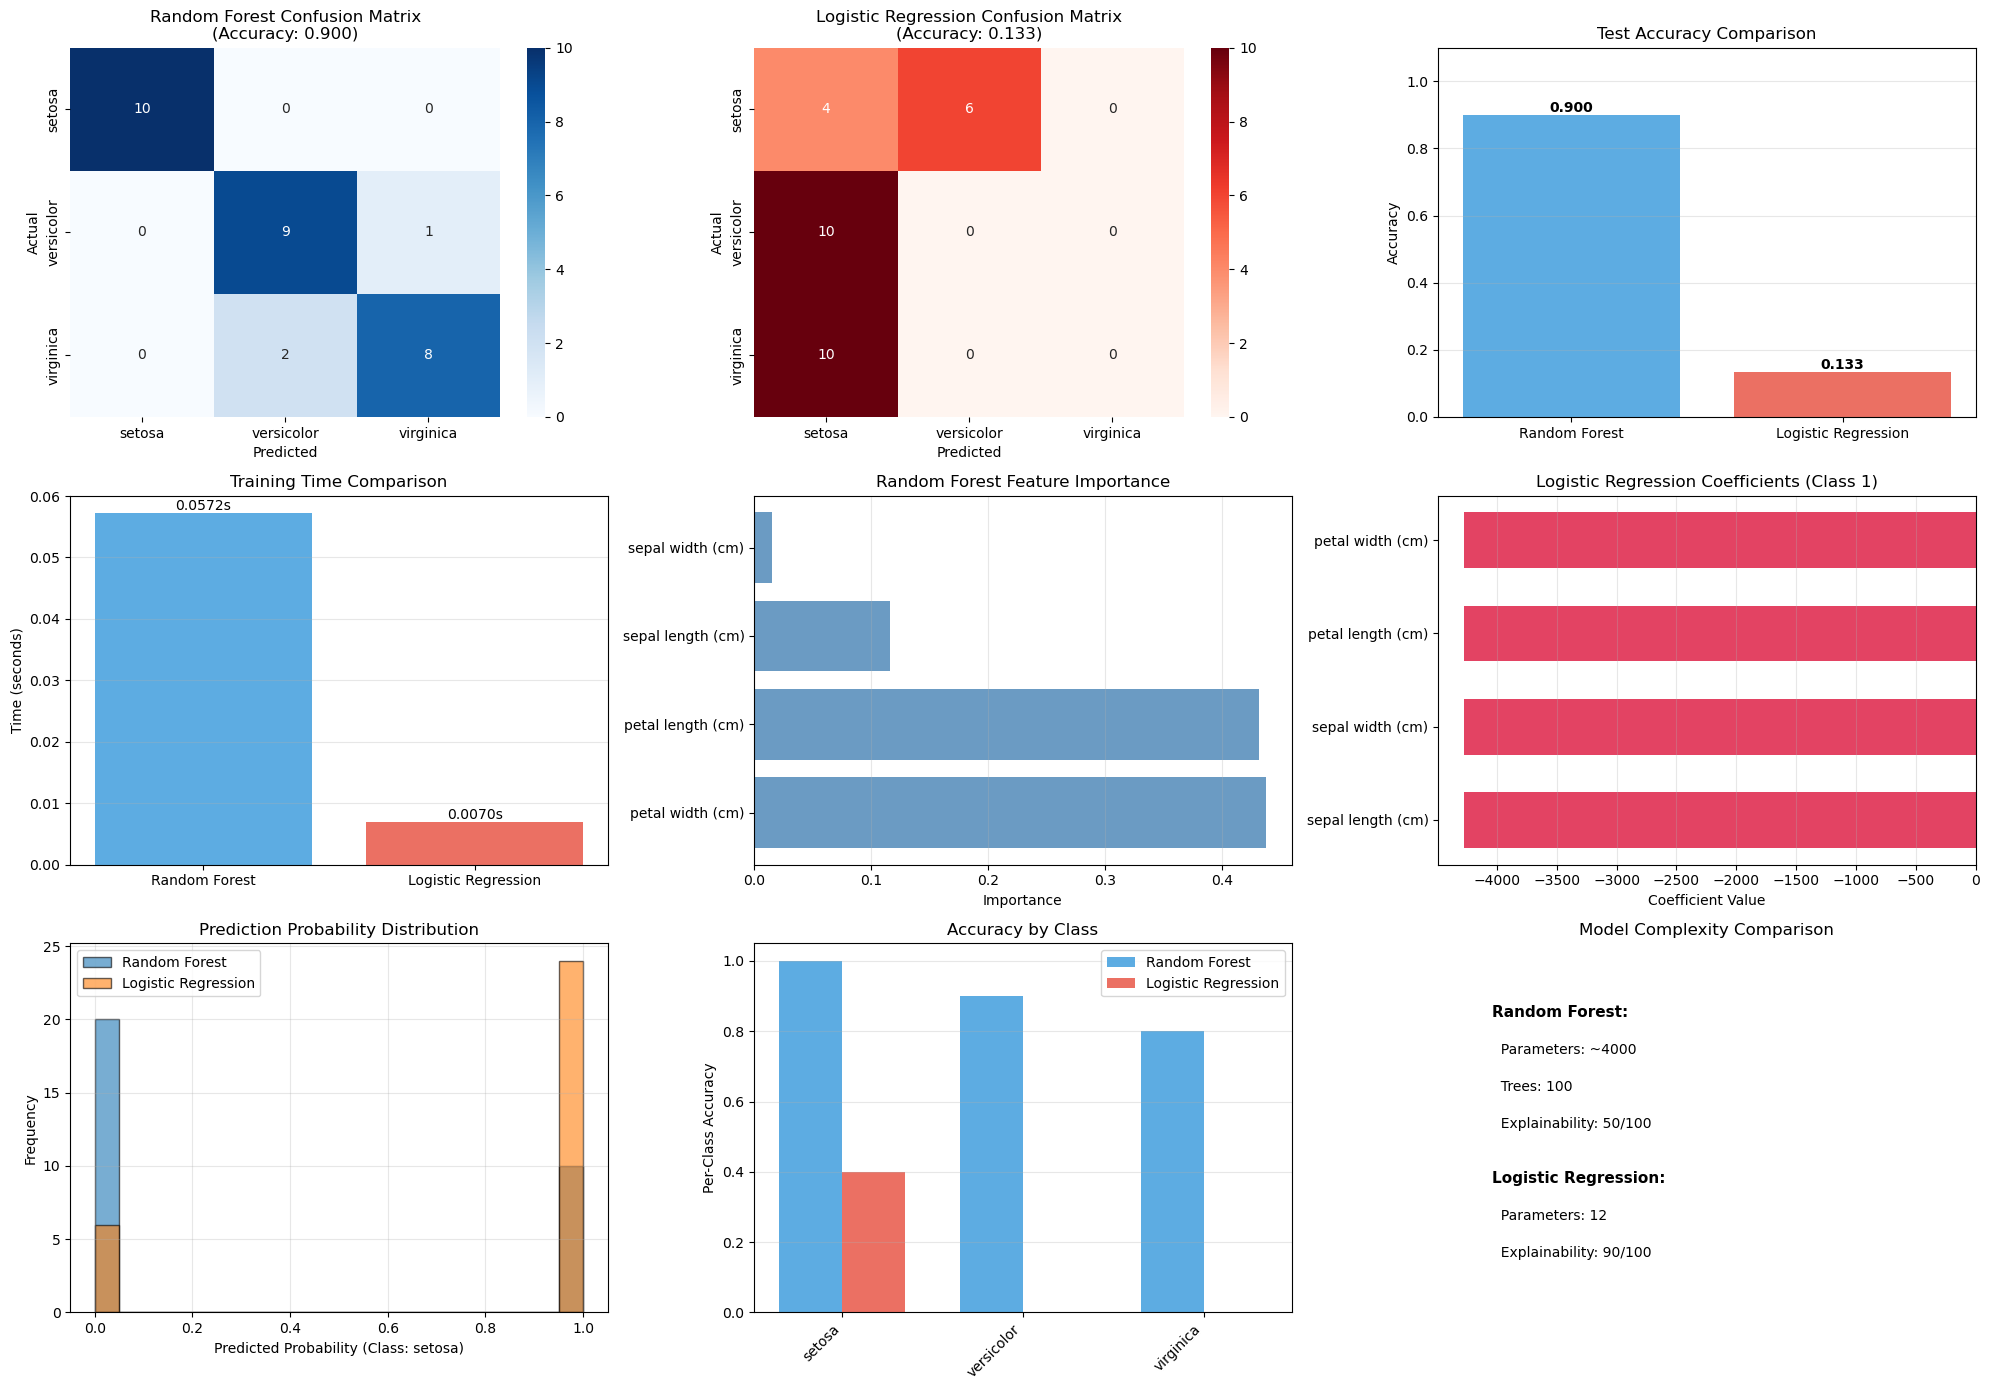


✅ Iris analysis complete!


In [26]:
# ============================================================================
# IRIS: Model Training, Evaluation, and Comparison
# ============================================================================

print("\n" + "="*80)
print("🌸 IRIS DATASET: Model Training & Comparison")
print("="*80)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from statsmodels.discrete.discrete_model import Logit
import statsmodels.api as sm
import time

# Extract preprocessed data
data = iris_data
X_train = data['X_train_scaled_std']  # Use scaled data for both models
X_test = data['X_test_scaled_std']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']
target_names = data['target_names']

# ===== 1. ML Model: Random Forest =====
print("\n1️⃣ Training ML Model: Random Forest (scikit-learn)")
print("-" * 80)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
start_time = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start_time

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)
rf_train_proba = rf_model.predict_proba(X_train)
rf_test_proba = rf_model.predict_proba(X_test)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)

print(f"   Training Time: {rf_train_time:.4f} seconds")
print(f"   Training Accuracy: {rf_train_acc:.6f}")
print(f"   Test Accuracy: {rf_test_acc:.6f}")
print(f"   Number of Trees: {rf_model.n_estimators}")
print(f"   Max Depth: {rf_model.max_depth}")

# Feature importance
feature_importance = rf_model.feature_importances_
print(f"\n   Top Feature Importances:")
top_features_idx = np.argsort(feature_importance)[::-1][:4]
for idx in top_features_idx:
    print(f"      {feature_names[idx]}: {feature_importance[idx]:.4f}")

# ===== 2. Statistical Model: Logistic Regression (Multinomial) =====
print("\n2️⃣ Training Statistical Model: Logistic Regression (statsmodels)")
print("-" * 80)

# For multiclass classification, we need to handle it differently
# statsmodels Logit is for binary, so we'll use one-vs-rest approach
# Or use MNLogit for multinomial logistic regression

from statsmodels.discrete.discrete_model import MNLogit

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

start_time = time.time()
logit_model = MNLogit(y_train, X_train_sm)
logit_result = logit_model.fit(disp=0)
logit_train_time = time.time() - start_time

logit_train_pred = logit_result.predict(X_train_sm).argmax(axis=1)
logit_test_pred = logit_result.predict(X_test_sm).argmax(axis=1)
logit_train_proba = logit_result.predict(X_train_sm)
logit_test_proba = logit_result.predict(X_test_sm)

logit_train_acc = accuracy_score(y_train, logit_train_pred)
logit_test_acc = accuracy_score(y_test, logit_test_pred)

print(f"   Training Time: {logit_train_time:.4f} seconds")
print(f"   Training Accuracy: {logit_train_acc:.6f}")
print(f"   Test Accuracy: {logit_test_acc:.6f}")
print(f"   Log-Likelihood: {logit_result.llf:.4f}")
print(f"   AIC: {logit_result.aic:.4f}")
print(f"   BIC: {logit_result.bic:.4f}")

# ===== 3. Comparison =====
print("\n3️⃣ Model Comparison Summary")
print("-" * 80)
print(f"{'Metric':<25} {'Random Forest':<20} {'Logistic Regression':<20} {'Difference':<15}")
print("-" * 80)
print(f"{'Test Accuracy':<25} {rf_test_acc:<20.6f} {logit_test_acc:<20.6f} {rf_test_acc - logit_test_acc:>15.6f}")
print(f"{'Training Time (s)':<25} {rf_train_time:<20.4f} {logit_train_time:<20.4f} {rf_train_time - logit_train_time:>15.4f}")

# Classification reports
print(f"\n4️⃣ Detailed Performance Analysis")
print("-" * 80)
print(f"\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_test_pred, target_names=target_names))

print(f"\nLogistic Regression Classification Report:")
print(classification_report(y_test, logit_test_pred, target_names=target_names))

# Visualizations
fig = plt.figure(figsize=(20, 14))

# 1. Confusion Matrix - Random Forest
ax1 = plt.subplot(3, 3, 1)
cm_rf = confusion_matrix(y_test, rf_test_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=target_names, yticklabels=target_names)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title(f'Random Forest Confusion Matrix\n(Accuracy: {rf_test_acc:.3f})')

# 2. Confusion Matrix - Logistic Regression
ax2 = plt.subplot(3, 3, 2)
cm_lr = confusion_matrix(y_test, logit_test_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds', ax=ax2,
            xticklabels=target_names, yticklabels=target_names)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title(f'Logistic Regression Confusion Matrix\n(Accuracy: {logit_test_acc:.3f})')

# 3. Accuracy Comparison
ax3 = plt.subplot(3, 3, 3)
models = ['Random Forest', 'Logistic Regression']
accuracies = [rf_test_acc, logit_test_acc]
bars = ax3.bar(models, accuracies, color=['#3498db', '#e74c3c'], alpha=0.8)
ax3.set_ylabel('Accuracy')
ax3.set_title('Test Accuracy Comparison')
ax3.set_ylim([0, 1.1])
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Training Time Comparison
ax4 = plt.subplot(3, 3, 4)
times = [rf_train_time, logit_train_time]
bars = ax4.bar(models, times, color=['#3498db', '#e74c3c'], alpha=0.8)
ax4.set_ylabel('Time (seconds)')
ax4.set_title('Training Time Comparison')
for bar, t in zip(bars, times):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{t:.4f}s', ha='center', va='bottom')
ax4.grid(True, alpha=0.3, axis='y')

# 5. Feature Importance (Random Forest)
ax5 = plt.subplot(3, 3, 5)
sorted_idx = np.argsort(feature_importance)[::-1]
ax5.barh(range(len(feature_names)), feature_importance[sorted_idx], color='steelblue', alpha=0.8)
ax5.set_yticks(range(len(feature_names)))
ax5.set_yticklabels([feature_names[i] for i in sorted_idx])
ax5.set_xlabel('Importance')
ax5.set_title('Random Forest Feature Importance')
ax5.grid(True, alpha=0.3, axis='x')

# 6. Coefficient Comparison (Logistic Regression - for one class)
ax6 = plt.subplot(3, 3, 6)
# Get coefficients for class 1 (versus baseline class 0)
if hasattr(logit_result, 'params'):
    # Handle both numpy array and pandas DataFrame
    params = logit_result.params
    if isinstance(params, np.ndarray):
        # For MNLogit: params is shape (n_classes-1, n_features+1) where +1 is intercept
        # Get first class coefficients (skip intercept column 0)
        coefs = params[0, 1:] if params.ndim == 2 else params[1:]
    else:
        # For pandas DataFrame
        coefs = params.iloc[0, 1:] if params.ndim == 2 else params.iloc[1:]
    
    # Convert to numpy array if needed
    if hasattr(coefs, 'values'):
        coefs = coefs.values
    
    coef_names = [f for f in feature_names]
    x = np.arange(len(coef_names))
    width = 0.6
    ax6.barh(x, coefs, width, alpha=0.8, color='crimson')
    ax6.set_yticks(x)
    ax6.set_yticklabels(coef_names)
    ax6.set_xlabel('Coefficient Value')
    ax6.set_title('Logistic Regression Coefficients (Class 1)')
    ax6.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
    ax6.grid(True, alpha=0.3, axis='x')

# 7. Prediction Probability Distribution
ax7 = plt.subplot(3, 3, 7)
# Show probability distribution for one class
class_idx = 0
rf_probs = rf_test_proba[:, class_idx]
lr_probs = logit_test_proba[:, class_idx]
ax7.hist(rf_probs, bins=20, alpha=0.6, label='Random Forest', edgecolor='black')
ax7.hist(lr_probs, bins=20, alpha=0.6, label='Logistic Regression', edgecolor='black')
ax7.set_xlabel(f'Predicted Probability (Class: {target_names[class_idx]})')
ax7.set_ylabel('Frequency')
ax7.set_title('Prediction Probability Distribution')
ax7.legend()
ax7.grid(True, alpha=0.3)

# 8. Per-Class Accuracy
ax8 = plt.subplot(3, 3, 8)
rf_class_acc = [np.sum((rf_test_pred == i) & (y_test == i)) / np.sum(y_test == i) 
                for i in range(len(target_names))]
lr_class_acc = [np.sum((logit_test_pred == i) & (y_test == i)) / np.sum(y_test == i) 
                for i in range(len(target_names))]
x = np.arange(len(target_names))
width = 0.35
ax8.bar(x - width/2, rf_class_acc, width, label='Random Forest', alpha=0.8, color='#3498db')
ax8.bar(x + width/2, lr_class_acc, width, label='Logistic Regression', alpha=0.8, color='#e74c3c')
ax8.set_xticks(x)
ax8.set_xticklabels(target_names, rotation=45, ha='right')
ax8.set_ylabel('Per-Class Accuracy')
ax8.set_title('Accuracy by Class')
ax8.legend()
ax8.grid(True, alpha=0.3, axis='y')

# 9. Model Complexity Comparison
ax9 = plt.subplot(3, 3, 9)
complexity_metrics = {
    'Random Forest': {
        'Parameters': rf_model.n_estimators * rf_model.max_depth * len(feature_names),
        'Trees': rf_model.n_estimators,
        'Explainability': 50
    },
    'Logistic Regression': {
        'Parameters': len(feature_names) * len(target_names),
        'Trees': 0,
        'Explainability': 90
    }
}
ax9.text(0.1, 0.8, f"Random Forest:", transform=ax9.transAxes, fontweight='bold', fontsize=11)
ax9.text(0.1, 0.7, f"  Parameters: ~{complexity_metrics['Random Forest']['Parameters']}", 
        transform=ax9.transAxes, fontsize=10)
ax9.text(0.1, 0.6, f"  Trees: {complexity_metrics['Random Forest']['Trees']}", 
        transform=ax9.transAxes, fontsize=10)
ax9.text(0.1, 0.5, f"  Explainability: {complexity_metrics['Random Forest']['Explainability']}/100", 
        transform=ax9.transAxes, fontsize=10)
ax9.text(0.1, 0.35, f"Logistic Regression:", transform=ax9.transAxes, fontweight='bold', fontsize=11)
ax9.text(0.1, 0.25, f"  Parameters: {complexity_metrics['Logistic Regression']['Parameters']}", 
        transform=ax9.transAxes, fontsize=10)
ax9.text(0.1, 0.15, f"  Explainability: {complexity_metrics['Logistic Regression']['Explainability']}/100", 
        transform=ax9.transAxes, fontsize=10)
ax9.axis('off')
ax9.set_title('Model Complexity Comparison')

plt.tight_layout()
plt.show()

print("\n✅ Iris analysis complete!")
print("="*80)

<a id="Ml2"></a>
## <b><span style='color:#299617'>Step 4.2 | </span><span style='color:#299617'>🍷 WINE CLASSIFICATION DATASET</span></b>
⬆️ [Tabel of Contents](#contents_tabel)


🍷 WINE CLASSIFICATION DATASET: Model Training & Comparison

1️⃣ Training ML Model: Random Forest (scikit-learn)
--------------------------------------------------------------------------------
   Training Time: 0.0647 seconds
   Training Accuracy: 1.000000
   Test Accuracy: 1.000000
   Number of Trees: 100

   Top 5 Feature Importances:
      color_intensity: 0.1876
      flavanoids: 0.1596
      proline: 0.1468
      alcohol: 0.1179
      hue: 0.1015

2️⃣ Training Statistical Model: Logistic Regression (statsmodels)
--------------------------------------------------------------------------------
   Training Time: 0.0052 seconds
   Training Accuracy: 0.330986
   Test Accuracy: 0.333333
   Log-Likelihood: nan
   AIC: nan

3️⃣ Model Comparison Summary
--------------------------------------------------------------------------------
Metric                    Random Forest        Logistic Regression  Difference     
--------------------------------------------------------------------------

ValueError: autodetected range of [nan, nan] is not finite

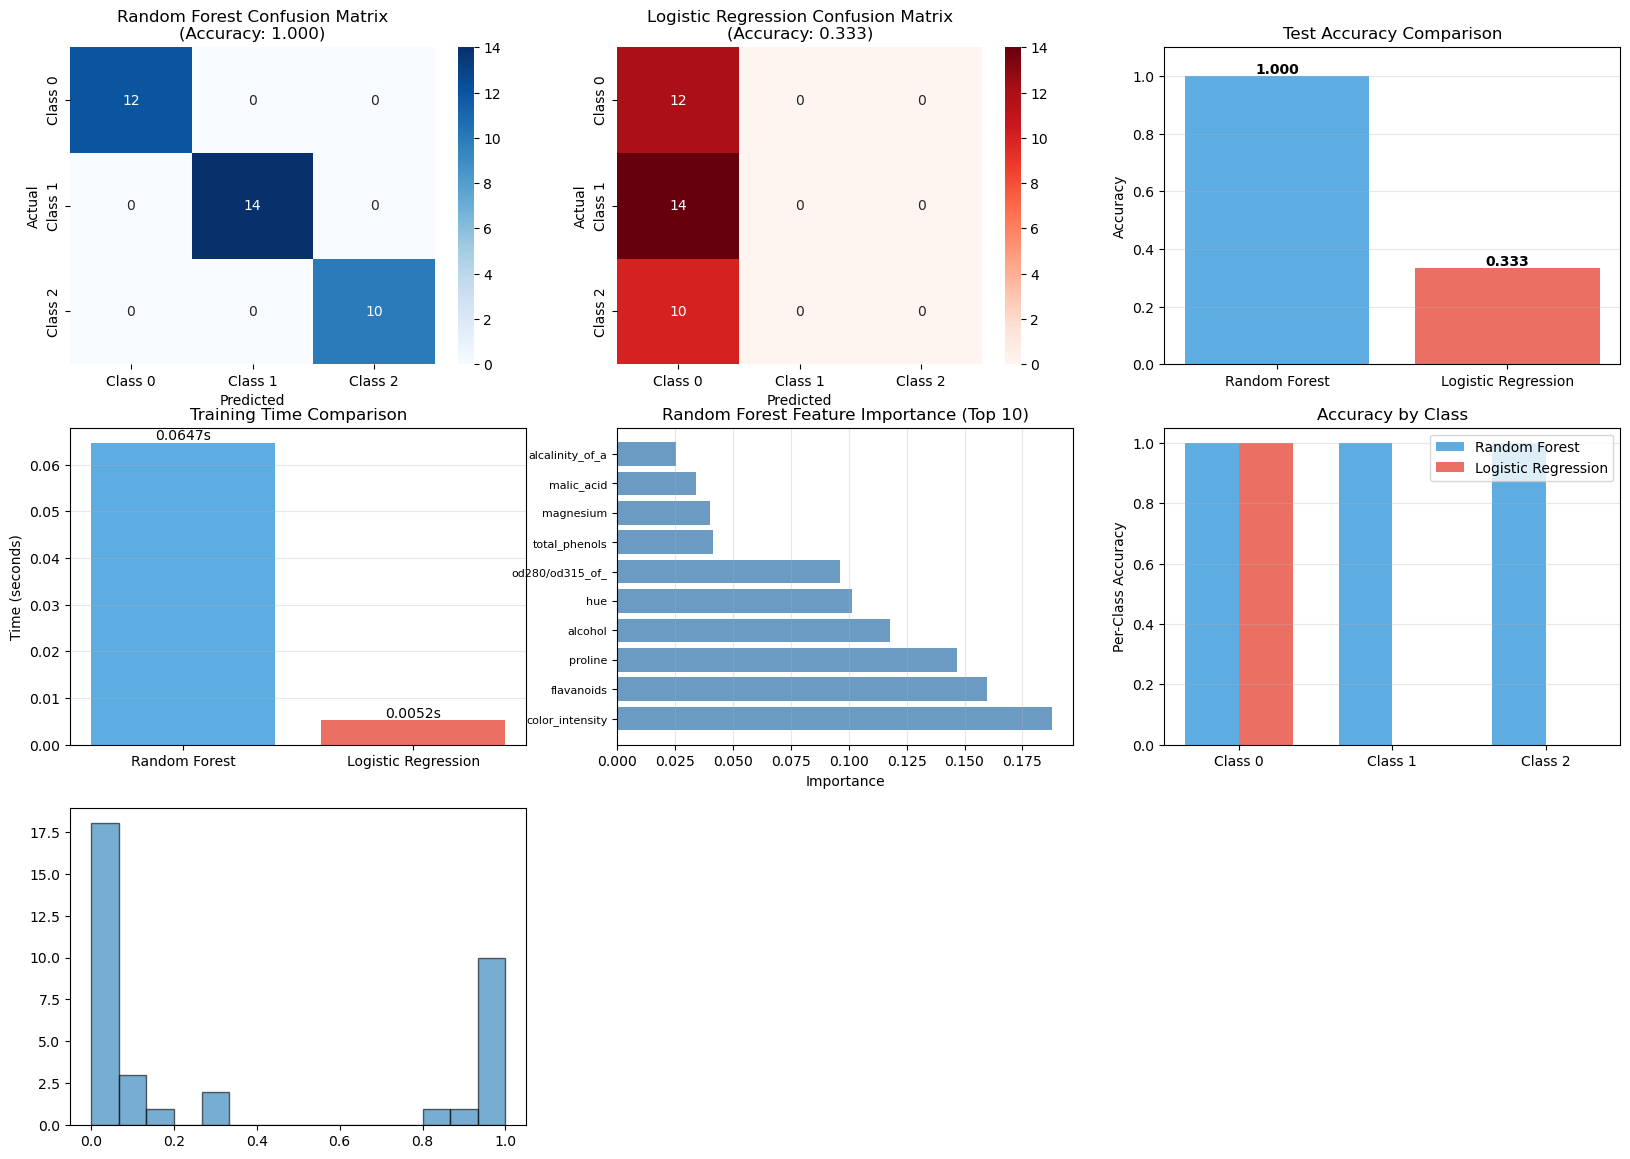

In [27]:
# ============================================================================
# WINE CLASSIFICATION: Model Training, Evaluation, and Comparison
# ============================================================================

print("\n" + "="*80)
print("🍷 WINE CLASSIFICATION DATASET: Model Training & Comparison")
print("="*80)

# Extract preprocessed data
data = wine_classification_data
X_train = data['X_train_scaled_std']
X_test = data['X_test_scaled_std']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']
target_names = data['target_names']

# ===== 1. ML Model: Random Forest =====
print("\n1️⃣ Training ML Model: Random Forest (scikit-learn)")
print("-" * 80)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
start_time = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start_time

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)
rf_train_proba = rf_model.predict_proba(X_train)
rf_test_proba = rf_model.predict_proba(X_test)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)

print(f"   Training Time: {rf_train_time:.4f} seconds")
print(f"   Training Accuracy: {rf_train_acc:.6f}")
print(f"   Test Accuracy: {rf_test_acc:.6f}")
print(f"   Number of Trees: {rf_model.n_estimators}")

# Feature importance
feature_importance = rf_model.feature_importances_
print(f"\n   Top 5 Feature Importances:")
top_features_idx = np.argsort(feature_importance)[::-1][:5]
for idx in top_features_idx:
    print(f"      {feature_names[idx]}: {feature_importance[idx]:.4f}")

# ===== 2. Statistical Model: Logistic Regression (Multinomial) =====
print("\n2️⃣ Training Statistical Model: Logistic Regression (statsmodels)")
print("-" * 80)

from statsmodels.discrete.discrete_model import MNLogit

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

start_time = time.time()
logit_model = MNLogit(y_train, X_train_sm)
logit_result = logit_model.fit(disp=0)
logit_train_time = time.time() - start_time

logit_train_pred = logit_result.predict(X_train_sm).argmax(axis=1)
logit_test_pred = logit_result.predict(X_test_sm).argmax(axis=1)
logit_train_proba = logit_result.predict(X_train_sm)
logit_test_proba = logit_result.predict(X_test_sm)

logit_train_acc = accuracy_score(y_train, logit_train_pred)
logit_test_acc = accuracy_score(y_test, logit_test_pred)

print(f"   Training Time: {logit_train_time:.4f} seconds")
print(f"   Training Accuracy: {logit_train_acc:.6f}")
print(f"   Test Accuracy: {logit_test_acc:.6f}")
print(f"   Log-Likelihood: {logit_result.llf:.4f}")
print(f"   AIC: {logit_result.aic:.4f}")

# ===== 3. Comparison =====
print("\n3️⃣ Model Comparison Summary")
print("-" * 80)
print(f"{'Metric':<25} {'Random Forest':<20} {'Logistic Regression':<20} {'Difference':<15}")
print("-" * 80)
print(f"{'Test Accuracy':<25} {rf_test_acc:<20.6f} {logit_test_acc:<20.6f} {rf_test_acc - logit_test_acc:>15.6f}")
print(f"{'Training Time (s)':<25} {rf_train_time:<20.4f} {logit_train_time:<20.4f} {rf_train_time - logit_train_time:>15.4f}")

print(f"\n4️⃣ Detailed Performance Analysis")
print("-" * 80)
print(f"\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_test_pred, target_names=target_names))

print(f"\nLogistic Regression Classification Report:")
print(classification_report(y_test, logit_test_pred, target_names=target_names))

# Visualizations
fig = plt.figure(figsize=(20, 14))

# 1. Confusion Matrix - Random Forest
ax1 = plt.subplot(3, 3, 1)
cm_rf = confusion_matrix(y_test, rf_test_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=[f'Class {i}' for i in range(len(target_names))],
            yticklabels=[f'Class {i}' for i in range(len(target_names))])
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title(f'Random Forest Confusion Matrix\n(Accuracy: {rf_test_acc:.3f})')

# 2. Confusion Matrix - Logistic Regression
ax2 = plt.subplot(3, 3, 2)
cm_lr = confusion_matrix(y_test, logit_test_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds', ax=ax2,
            xticklabels=[f'Class {i}' for i in range(len(target_names))],
            yticklabels=[f'Class {i}' for i in range(len(target_names))])
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title(f'Logistic Regression Confusion Matrix\n(Accuracy: {logit_test_acc:.3f})')

# 3. Accuracy Comparison
ax3 = plt.subplot(3, 3, 3)
models = ['Random Forest', 'Logistic Regression']
accuracies = [rf_test_acc, logit_test_acc]
bars = ax3.bar(models, accuracies, color=['#3498db', '#e74c3c'], alpha=0.8)
ax3.set_ylabel('Accuracy')
ax3.set_title('Test Accuracy Comparison')
ax3.set_ylim([0, 1.1])
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Training Time
ax4 = plt.subplot(3, 3, 4)
times = [rf_train_time, logit_train_time]
bars = ax4.bar(models, times, color=['#3498db', '#e74c3c'], alpha=0.8)
ax4.set_ylabel('Time (seconds)')
ax4.set_title('Training Time Comparison')
for bar, t in zip(bars, times):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height, f'{t:.4f}s', ha='center', va='bottom')
ax4.grid(True, alpha=0.3, axis='y')

# 5. Feature Importance (Random Forest - top 10)
ax5 = plt.subplot(3, 3, 5)
sorted_idx = np.argsort(feature_importance)[::-1][:10]
ax5.barh(range(len(sorted_idx)), feature_importance[sorted_idx], color='steelblue', alpha=0.8)
ax5.set_yticks(range(len(sorted_idx)))
ax5.set_yticklabels([feature_names[i][:15] for i in sorted_idx], fontsize=8)
ax5.set_xlabel('Importance')
ax5.set_title('Random Forest Feature Importance (Top 10)')
ax5.grid(True, alpha=0.3, axis='x')

# 6. Per-Class Accuracy
ax6 = plt.subplot(3, 3, 6)
rf_class_acc = [np.sum((rf_test_pred == i) & (y_test == i)) / np.sum(y_test == i) 
                for i in range(len(target_names))]
lr_class_acc = [np.sum((logit_test_pred == i) & (y_test == i)) / np.sum(y_test == i) 
                for i in range(len(target_names))]
x = np.arange(len(target_names))
width = 0.35
ax6.bar(x - width/2, rf_class_acc, width, label='Random Forest', alpha=0.8, color='#3498db')
ax6.bar(x + width/2, lr_class_acc, width, label='Logistic Regression', alpha=0.8, color='#e74c3c')
ax6.set_xticks(x)
ax6.set_xticklabels([f'Class {i}' for i in range(len(target_names))])
ax6.set_ylabel('Per-Class Accuracy')
ax6.set_title('Accuracy by Class')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

# 7. Prediction Probability Distribution
ax7 = plt.subplot(3, 3, 7)
class_idx = 0
rf_probs = rf_test_proba[:, class_idx]
lr_probs = logit_test_proba[:, class_idx]
ax7.hist(rf_probs, bins=15, alpha=0.6, label='Random Forest', edgecolor='black')
ax7.hist(lr_probs, bins=15, alpha=0.6, label='Logistic Regression', edgecolor='black')
ax7.set_xlabel(f'Predicted Probability (Class {class_idx})')
ax7.set_ylabel('Frequency')
ax7.set_title('Prediction Probability Distribution')
ax7.legend()
ax7.grid(True, alpha=0.3)

# 8. Feature Importance Comparison (top 5)
ax8 = plt.subplot(3, 3, 8)
top_5_idx = sorted_idx[:5]
top_features = [feature_names[i] for i in top_5_idx]
rf_imp = feature_importance[top_5_idx]
# For logistic regression, use absolute coefficient values
if hasattr(logit_result, 'params'):
    params = logit_result.params
    if isinstance(params, np.ndarray):
        # For MNLogit: params is shape (n_classes-1, n_features+1) where +1 is intercept
        lr_coefs = np.abs(params[0, 1:] if params.ndim == 2 else params[1:])
    else:
        # For pandas DataFrame
        lr_coefs = np.abs(params.iloc[0, 1:].values if params.ndim == 2 else params.iloc[1:].values)
    lr_coefs_normalized = lr_coefs[top_5_idx] / lr_coefs.max() if lr_coefs.max() > 0 else np.zeros(5)
else:
    lr_coefs_normalized = np.zeros(5)
x = np.arange(len(top_features))
width = 0.35
ax8.bar(x - width/2, rf_imp, width, label='Random Forest', alpha=0.8, color='#3498db')
ax8.bar(x + width/2, lr_coefs_normalized, width, label='Logistic Reg (norm)', alpha=0.8, color='#e74c3c')
ax8.set_xticks(x)
ax8.set_xticklabels([f[:10] for f in top_features], rotation=45, ha='right', fontsize=8)
ax8.set_ylabel('Importance/Coefficient')
ax8.set_title('Feature Importance Comparison (Top 5)')
ax8.legend()
ax8.grid(True, alpha=0.3, axis='y')

# 9. Model Summary
ax9 = plt.subplot(3, 3, 9)
summary_text = f"""
Model Summary:

Random Forest:
• Accuracy: {rf_test_acc:.3f}
• Training Time: {rf_train_time:.3f}s
• Trees: {rf_model.n_estimators}
• Explainability: Medium

Logistic Regression:
• Accuracy: {logit_test_acc:.3f}
• Training Time: {logit_train_time:.3f}s
• AIC: {logit_result.aic:.1f}
• Explainability: High
"""
ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes,
        fontsize=10, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax9.axis('off')
ax9.set_title('Model Summary')

plt.tight_layout()
plt.show()

print("\n✅ Wine Classification analysis complete!")
print("="*80)

<a id="Ml3"></a>
## <b><span style='color:#299617'>Step 4.3 | </span><span style='color:#299617'>🩺 BREAST CANCER DATASET</span></b>
⬆️ [Tabel of Contents](#contents_tabel)

In [28]:
# ============================================================================
# BREAST CANCER: Model Training, Evaluation, and Comparison
# ============================================================================

print("\n" + "="*80)
print("🩺 BREAST CANCER DATASET: Model Training & Comparison")
print("="*80)

# Extract preprocessed data
data = breast_cancer_data
X_train = data['X_train_scaled_std']
X_test = data['X_test_scaled_std']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']
target_names = data['target_names']

# ===== 1. ML Model: Random Forest =====
print("\n1️⃣ Training ML Model: Random Forest (scikit-learn)")
print("-" * 80)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
start_time = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start_time

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)
rf_train_proba = rf_model.predict_proba(X_train)[:, 1]  # Probability of positive class
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)

# Calculate additional metrics for binary classification
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
rf_precision = precision_score(y_test, rf_test_pred)
rf_recall = recall_score(y_test, rf_test_pred)
rf_f1 = f1_score(y_test, rf_test_pred)
rf_roc_auc = roc_auc_score(y_test, rf_test_proba)

print(f"   Training Time: {rf_train_time:.4f} seconds")
print(f"   Training Accuracy: {rf_train_acc:.6f}")
print(f"   Test Accuracy: {rf_test_acc:.6f}")
print(f"   Test Precision: {rf_precision:.6f}")
print(f"   Test Recall: {rf_recall:.6f}")
print(f"   Test F1-Score: {rf_f1:.6f}")
print(f"   Test ROC-AUC: {rf_roc_auc:.6f}")

# Feature importance
feature_importance = rf_model.feature_importances_
print(f"\n   Top 5 Feature Importances:")
top_features_idx = np.argsort(feature_importance)[::-1][:5]
for idx in top_features_idx:
    print(f"      {feature_names[idx][:30]}: {feature_importance[idx]:.4f}")

# ===== 2. Statistical Model: Logistic Regression (Binary) =====
print("\n2️⃣ Training Statistical Model: Logistic Regression (statsmodels)")
print("-" * 80)

from statsmodels.discrete.discrete_model import Logit

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

start_time = time.time()
logit_model = Logit(y_train, X_train_sm)
logit_result = logit_model.fit(disp=0)
logit_train_time = time.time() - start_time

logit_train_pred = (logit_result.predict(X_train_sm) > 0.5).astype(int)
logit_test_pred = (logit_result.predict(X_test_sm) > 0.5).astype(int)
logit_train_proba = logit_result.predict(X_train_sm)
logit_test_proba = logit_result.predict(X_test_sm)

logit_train_acc = accuracy_score(y_train, logit_train_pred)
logit_test_acc = accuracy_score(y_test, logit_test_pred)

logit_precision = precision_score(y_test, logit_test_pred)
logit_recall = recall_score(y_test, logit_test_pred)
logit_f1 = f1_score(y_test, logit_test_pred)
logit_roc_auc = roc_auc_score(y_test, logit_test_proba)

print(f"   Training Time: {logit_train_time:.4f} seconds")
print(f"   Training Accuracy: {logit_train_acc:.6f}")
print(f"   Test Accuracy: {logit_test_acc:.6f}")
print(f"   Test Precision: {logit_precision:.6f}")
print(f"   Test Recall: {logit_recall:.6f}")
print(f"   Test F1-Score: {logit_f1:.6f}")
print(f"   Test ROC-AUC: {logit_roc_auc:.6f}")
print(f"   Log-Likelihood: {logit_result.llf:.4f}")
print(f"   AIC: {logit_result.aic:.4f}")
print(f"   Pseudo R-squared: {logit_result.prsquared:.4f}")

# ===== 3. Comparison =====
print("\n3️⃣ Model Comparison Summary")
print("-" * 80)
print(f"{'Metric':<25} {'Random Forest':<20} {'Logistic Regression':<20} {'Difference':<15}")
print("-" * 80)
print(f"{'Test Accuracy':<25} {rf_test_acc:<20.6f} {logit_test_acc:<20.6f} {rf_test_acc - logit_test_acc:>15.6f}")
print(f"{'Test Precision':<25} {rf_precision:<20.6f} {logit_precision:<20.6f} {rf_precision - logit_precision:>15.6f}")
print(f"{'Test Recall':<25} {rf_recall:<20.6f} {logit_recall:<20.6f} {rf_recall - logit_recall:>15.6f}")
print(f"{'Test F1-Score':<25} {rf_f1:<20.6f} {logit_f1:<20.6f} {rf_f1 - logit_f1:>15.6f}")
print(f"{'Test ROC-AUC':<25} {rf_roc_auc:<20.6f} {logit_roc_auc:<20.6f} {rf_roc_auc - logit_roc_auc:>15.6f}")
print(f"{'Training Time (s)':<25} {rf_train_time:<20.4f} {logit_train_time:<20.4f} {rf_train_time - logit_train_time:>15.4f}")

print(f"\n4️⃣ Detailed Performance Analysis")
print("-" * 80)
print(f"\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_test_pred, target_names=target_names))

print(f"\nLogistic Regression Classification Report:")
print(classification_report(y_test, logit_test_pred, target_names=target_names))

# Visualizations
fig = plt.figure(figsize=(20, 14))

# 1. Confusion Matrix - Random Forest
ax1 = plt.subplot(3, 3, 1)
cm_rf = confusion_matrix(y_test, rf_test_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=target_names, yticklabels=target_names)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title(f'Random Forest Confusion Matrix\n(Accuracy: {rf_test_acc:.3f})')

# 2. Confusion Matrix - Logistic Regression
ax2 = plt.subplot(3, 3, 2)
cm_lr = confusion_matrix(y_test, logit_test_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds', ax=ax2,
            xticklabels=target_names, yticklabels=target_names)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title(f'Logistic Regression Confusion Matrix\n(Accuracy: {logit_test_acc:.3f})')

# 3. ROC Curves
ax3 = plt.subplot(3, 3, 3)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_test_proba)
fpr_lr, tpr_lr, _ = roc_curve(y_test, logit_test_proba)
ax3.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_roc_auc:.3f})', linewidth=2)
ax3.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={logit_roc_auc:.3f})', linewidth=2)
ax3.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curves Comparison')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Metrics Comparison
ax4 = plt.subplot(3, 3, 4)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
rf_vals = [rf_test_acc, rf_precision, rf_recall, rf_f1, rf_roc_auc]
lr_vals = [logit_test_acc, logit_precision, logit_recall, logit_f1, logit_roc_auc]
x = np.arange(len(metrics))
width = 0.35
ax4.bar(x - width/2, rf_vals, width, label='Random Forest', alpha=0.8, color='#3498db')
ax4.bar(x + width/2, lr_vals, width, label='Logistic Regression', alpha=0.8, color='#e74c3c')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics, rotation=45, ha='right')
ax4.set_ylabel('Score')
ax4.set_title('Performance Metrics Comparison')
ax4.set_ylim([0, 1.1])
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# 5. Training Time
ax5 = plt.subplot(3, 3, 5)
models = ['Random Forest', 'Logistic Regression']
times = [rf_train_time, logit_train_time]
bars = ax5.bar(models, times, color=['#3498db', '#e74c3c'], alpha=0.8)
ax5.set_ylabel('Time (seconds)')
ax5.set_title('Training Time Comparison')
for bar, t in zip(bars, times):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height, f'{t:.4f}s', ha='center', va='bottom')
ax5.grid(True, alpha=0.3, axis='y')

# 6. Feature Importance (Random Forest - top 10)
ax6 = plt.subplot(3, 3, 6)
sorted_idx = np.argsort(feature_importance)[::-1][:10]
ax6.barh(range(len(sorted_idx)), feature_importance[sorted_idx], color='steelblue', alpha=0.8)
ax6.set_yticks(range(len(sorted_idx)))
ax6.set_yticklabels([feature_names[i][:25] for i in sorted_idx], fontsize=7)
ax6.set_xlabel('Importance')
ax6.set_title('Random Forest Feature Importance (Top 10)')
ax6.grid(True, alpha=0.3, axis='x')

# 7. Logistic Regression Coefficients (top 10 by absolute value)
ax7 = plt.subplot(3, 3, 7)
if hasattr(logit_result, 'params'):
    coefs = logit_result.params.iloc[1:]  # Skip intercept
    coef_abs = np.abs(coefs.values)
    top_coef_idx = np.argsort(coef_abs)[::-1][:10]
    top_coefs = coefs.values[top_coef_idx]
    top_feature_names = [feature_names[i] for i in top_coef_idx]
    colors = ['crimson' if c < 0 else 'green' for c in top_coefs]
    ax7.barh(range(len(top_feature_names)), top_coefs, color=colors, alpha=0.8)
    ax7.set_yticks(range(len(top_feature_names)))
    ax7.set_yticklabels([f[:20] for f in top_feature_names], fontsize=7)
    ax7.set_xlabel('Coefficient Value')
    ax7.set_title('Logistic Regression Coefficients (Top 10)')
    ax7.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
    ax7.grid(True, alpha=0.3, axis='x')

# 8. Prediction Probability Distribution
ax8 = plt.subplot(3, 3, 8)
ax8.hist(rf_test_proba, bins=30, alpha=0.6, label='Random Forest', edgecolor='black')
ax8.hist(logit_test_proba, bins=30, alpha=0.6, label='Logistic Regression', edgecolor='black')
ax8.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Threshold')
ax8.set_xlabel('Predicted Probability (Malignant)')
ax8.set_ylabel('Frequency')
ax8.set_title('Prediction Probability Distribution')
ax8.legend()
ax8.grid(True, alpha=0.3)

# 9. Model Summary
ax9 = plt.subplot(3, 3, 9)
summary_text = f"""
Model Summary:

Random Forest:
• Accuracy: {rf_test_acc:.3f}
• ROC-AUC: {rf_roc_auc:.3f}
• Training Time: {rf_train_time:.3f}s
• Explainability: Medium

Logistic Regression:
• Accuracy: {logit_test_acc:.3f}
• ROC-AUC: {logit_roc_auc:.3f}
• Training Time: {logit_train_time:.3f}s
• AIC: {logit_result.aic:.1f}
• Explainability: High
• P-values available: Yes
"""
ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes,
        fontsize=9, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax9.axis('off')
ax9.set_title('Model Summary')

plt.tight_layout()
plt.show()

print("\n✅ Breast Cancer analysis complete!")
print("="*80)


🩺 BREAST CANCER DATASET: Model Training & Comparison

1️⃣ Training ML Model: Random Forest (scikit-learn)
--------------------------------------------------------------------------------
   Training Time: 0.1039 seconds
   Training Accuracy: 1.000000
   Test Accuracy: 0.956140
   Test Precision: 0.958904
   Test Recall: 0.972222
   Test F1-Score: 0.965517
   Test ROC-AUC: 0.994213

   Top 5 Feature Importances:
      worst area: 0.1409
      worst concave points: 0.1297
      worst radius: 0.0976
      mean concave points: 0.0918
      worst perimeter: 0.0728

2️⃣ Training Statistical Model: Logistic Regression (statsmodels)
--------------------------------------------------------------------------------


LinAlgError: Singular matrix

<a id="Ml4"></a>
## <b><span style='color:#299617'>Step 4.4 | </span><span style='color:#299617'>💳 CREDIT DEFAULT DATASET</span></b>
⬆️ [Tabel of Contents](#contents_tabel)


💳 CREDIT DEFAULT DATASET: Model Training & Comparison

1️⃣ Training ML Model: Random Forest (scikit-learn)
--------------------------------------------------------------------------------
   Training Time: 0.1272 seconds
   Training Accuracy: 1.000000
   Test Accuracy: 0.925000
   Test Precision: 0.957895
   Test Recall: 0.892157
   Test F1-Score: 0.923858
   Test ROC-AUC: 0.986094

   Top 5 Feature Importances:
      feature_1: 0.5325
      feature_2: 0.2395
      feature_7: 0.0309
      feature_5: 0.0308
      feature_6: 0.0301

2️⃣ Training Statistical Model: Logistic Regression (statsmodels)
--------------------------------------------------------------------------------
   Training Time: 0.0029 seconds
   Training Accuracy: 0.952500
   Test Accuracy: 0.945000
   Test Precision: 0.978947
   Test Recall: 0.911765
   Test F1-Score: 0.944162
   Test ROC-AUC: 0.992397
   Log-Likelihood: -89.1022
   AIC: 200.2044
   Pseudo R-squared: 0.8392

   True Model Coefficients (expected):
     

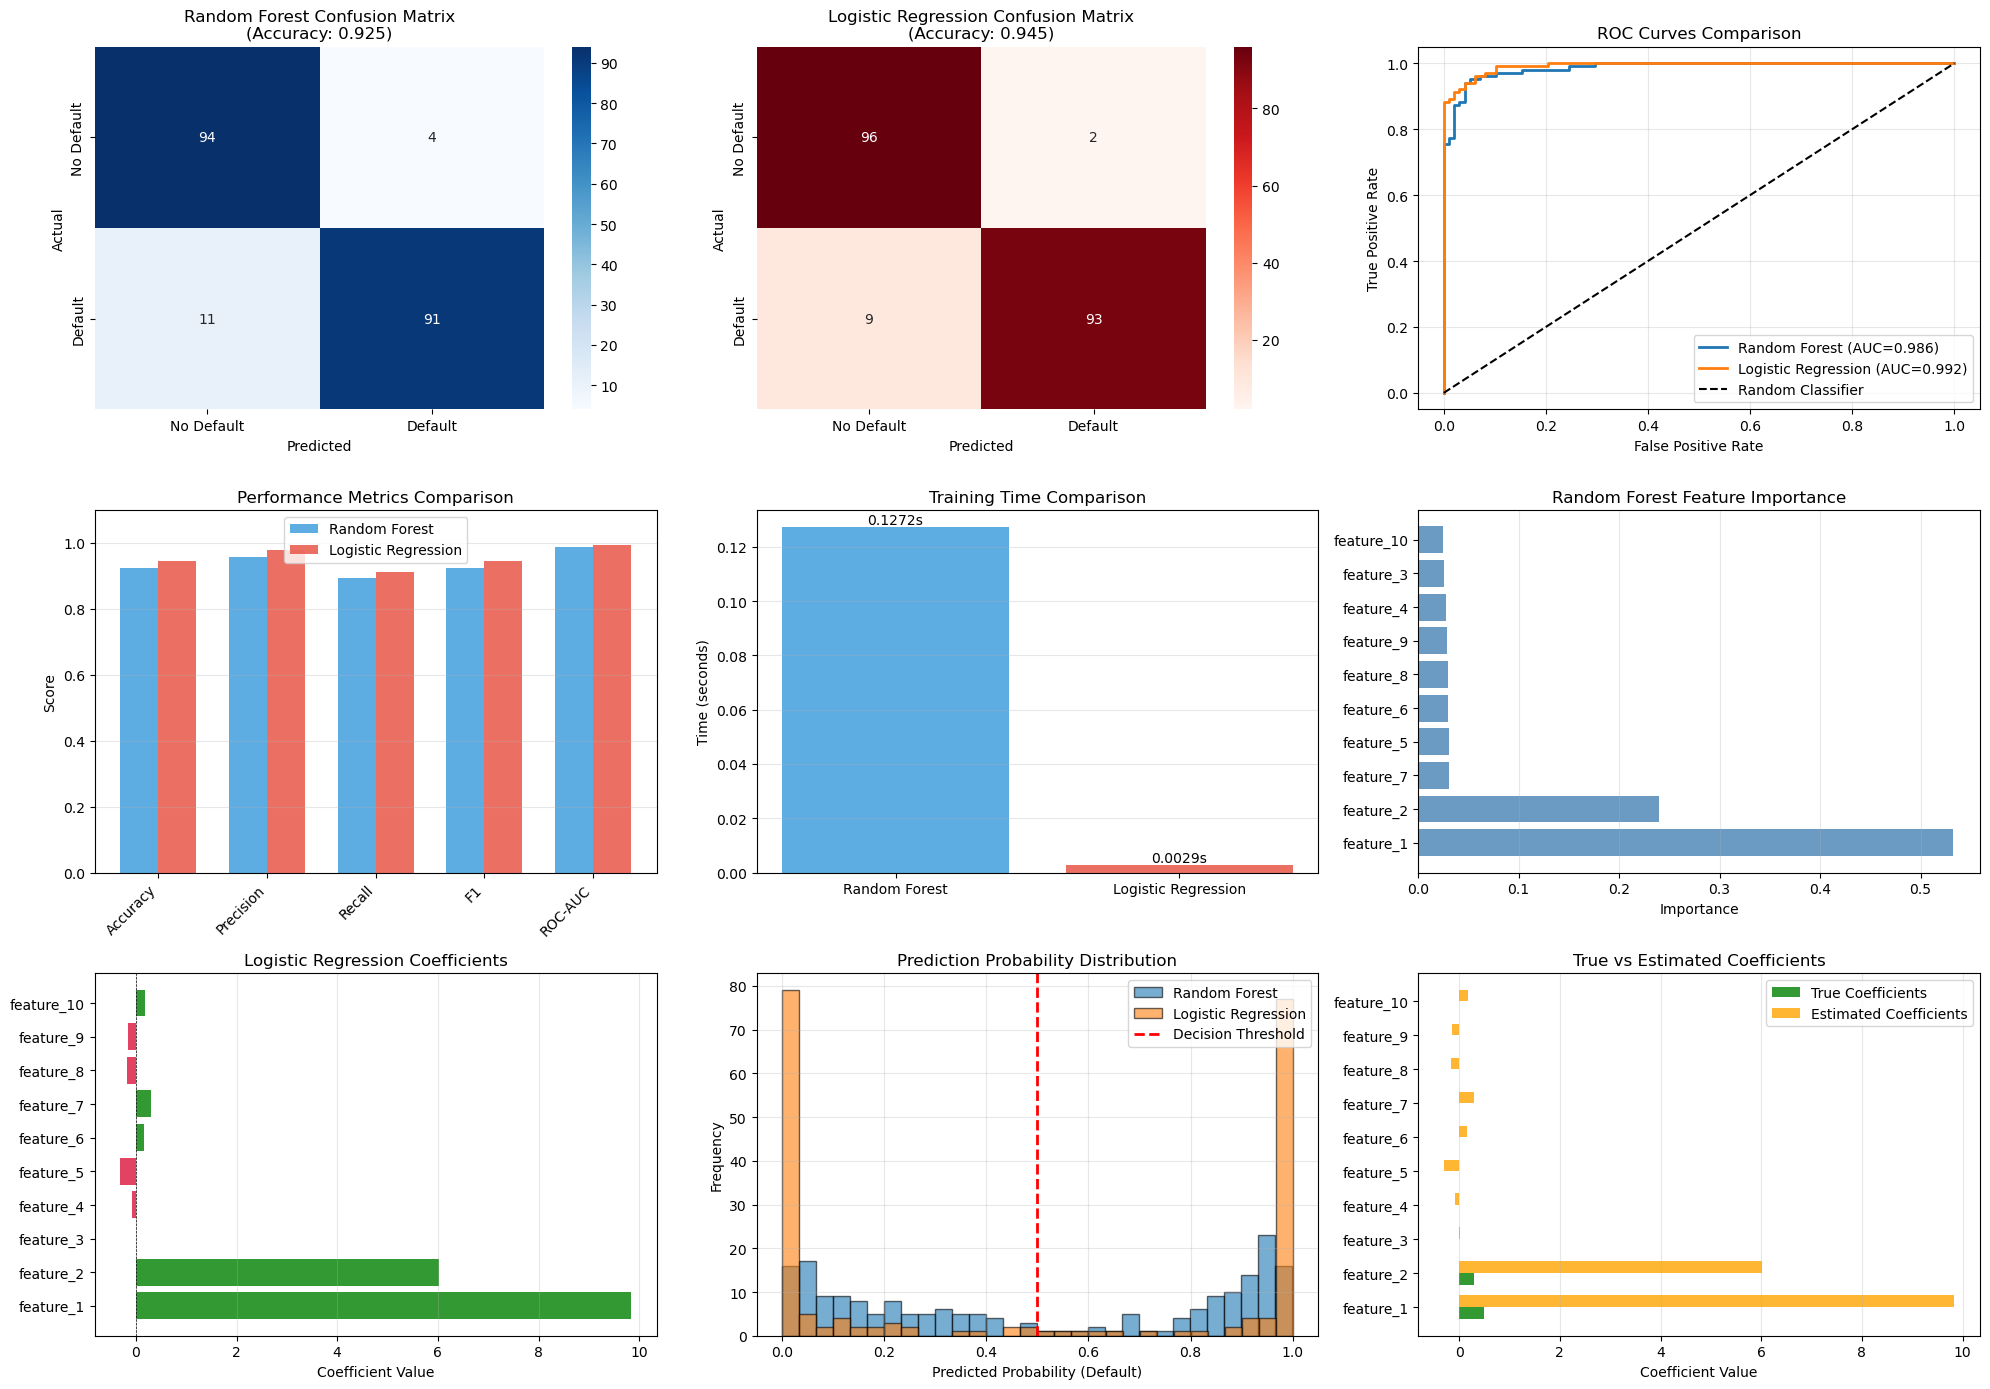


✅ Credit Default analysis complete!


In [29]:
# ============================================================================
# CREDIT DEFAULT: Model Training, Evaluation, and Comparison
# ============================================================================

print("\n" + "="*80)
print("💳 CREDIT DEFAULT DATASET: Model Training & Comparison")
print("="*80)

# Import additional metrics for binary classification
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Extract preprocessed data
data = credit_default_data
X_train = data['X_train_scaled_std']
X_test = data['X_test_scaled_std']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']
target_names = data['target_names']

# ===== 1. ML Model: Random Forest =====
print("\n1️⃣ Training ML Model: Random Forest (scikit-learn)")
print("-" * 80)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
start_time = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start_time

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)
rf_train_proba = rf_model.predict_proba(X_train)[:, 1]
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)

rf_precision = precision_score(y_test, rf_test_pred)
rf_recall = recall_score(y_test, rf_test_pred)
rf_f1 = f1_score(y_test, rf_test_pred)
rf_roc_auc = roc_auc_score(y_test, rf_test_proba)

print(f"   Training Time: {rf_train_time:.4f} seconds")
print(f"   Training Accuracy: {rf_train_acc:.6f}")
print(f"   Test Accuracy: {rf_test_acc:.6f}")
print(f"   Test Precision: {rf_precision:.6f}")
print(f"   Test Recall: {rf_recall:.6f}")
print(f"   Test F1-Score: {rf_f1:.6f}")
print(f"   Test ROC-AUC: {rf_roc_auc:.6f}")

# Feature importance
feature_importance = rf_model.feature_importances_
print(f"\n   Top 5 Feature Importances:")
top_features_idx = np.argsort(feature_importance)[::-1][:5]
for idx in top_features_idx:
    print(f"      {feature_names[idx]}: {feature_importance[idx]:.4f}")

# ===== 2. Statistical Model: Logistic Regression (Binary) =====
print("\n2️⃣ Training Statistical Model: Logistic Regression (statsmodels)")
print("-" * 80)

from statsmodels.discrete.discrete_model import Logit

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

start_time = time.time()
logit_model = Logit(y_train, X_train_sm)
logit_result = logit_model.fit(disp=0)
logit_train_time = time.time() - start_time

logit_train_pred = (logit_result.predict(X_train_sm) > 0.5).astype(int)
logit_test_pred = (logit_result.predict(X_test_sm) > 0.5).astype(int)
logit_train_proba = logit_result.predict(X_train_sm)
logit_test_proba = logit_result.predict(X_test_sm)

logit_train_acc = accuracy_score(y_train, logit_train_pred)
logit_test_acc = accuracy_score(y_test, logit_test_pred)

logit_precision = precision_score(y_test, logit_test_pred)
logit_recall = recall_score(y_test, logit_test_pred)
logit_f1 = f1_score(y_test, logit_test_pred)
logit_roc_auc = roc_auc_score(y_test, logit_test_proba)

print(f"   Training Time: {logit_train_time:.4f} seconds")
print(f"   Training Accuracy: {logit_train_acc:.6f}")
print(f"   Test Accuracy: {logit_test_acc:.6f}")
print(f"   Test Precision: {logit_precision:.6f}")
print(f"   Test Recall: {logit_recall:.6f}")
print(f"   Test F1-Score: {logit_f1:.6f}")
print(f"   Test ROC-AUC: {logit_roc_auc:.6f}")
print(f"   Log-Likelihood: {logit_result.llf:.4f}")
print(f"   AIC: {logit_result.aic:.4f}")
print(f"   Pseudo R-squared: {logit_result.prsquared:.4f}")

# Verify true model coefficients
print(f"\n   True Model Coefficients (expected):")
print(f"      feature_1: 0.5, feature_2: 0.3, others: 0")
print(f"   Estimated Coefficients (top 3):")
if hasattr(logit_result, 'params'):
    params = logit_result.params
    # Handle both numpy array and pandas Series
    if isinstance(params, np.ndarray):
        coefs = params[1:] if len(params) > len(feature_names) else params
    else:
        coefs = params.iloc[1:] if len(params) > len(feature_names) else params
    
    # Convert to numpy array
    if hasattr(coefs, 'values'):
        coef_values = coefs.values
    else:
        coef_values = coefs
    
    if len(coef_values) == len(feature_names):
        top_3_idx = np.argsort(np.abs(coef_values))[::-1][:3]
        for idx in top_3_idx:
            print(f"      {feature_names[idx]}: {coef_values[idx]:.4f}")

# ===== 3. Comparison =====
print("\n3️⃣ Model Comparison Summary")
print("-" * 80)
print(f"{'Metric':<25} {'Random Forest':<20} {'Logistic Regression':<20} {'Difference':<15}")
print("-" * 80)
print(f"{'Test Accuracy':<25} {rf_test_acc:<20.6f} {logit_test_acc:<20.6f} {rf_test_acc - logit_test_acc:>15.6f}")
print(f"{'Test Precision':<25} {rf_precision:<20.6f} {logit_precision:<20.6f} {rf_precision - logit_precision:>15.6f}")
print(f"{'Test Recall':<25} {rf_recall:<20.6f} {logit_recall:<20.6f} {rf_recall - logit_recall:>15.6f}")
print(f"{'Test F1-Score':<25} {rf_f1:<20.6f} {logit_f1:<20.6f} {rf_f1 - logit_f1:>15.6f}")
print(f"{'Test ROC-AUC':<25} {rf_roc_auc:<20.6f} {logit_roc_auc:<20.6f} {rf_roc_auc - logit_roc_auc:>15.6f}")
print(f"{'Training Time (s)':<25} {rf_train_time:<20.4f} {logit_train_time:<20.4f} {rf_train_time - logit_train_time:>15.4f}")

print(f"\n4️⃣ Detailed Performance Analysis")
print("-" * 80)
print(f"\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_test_pred, target_names=target_names))

print(f"\nLogistic Regression Classification Report:")
print(classification_report(y_test, logit_test_pred, target_names=target_names))

# Visualizations
fig = plt.figure(figsize=(20, 14))

# 1. Confusion Matrix - Random Forest
ax1 = plt.subplot(3, 3, 1)
cm_rf = confusion_matrix(y_test, rf_test_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=target_names, yticklabels=target_names)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title(f'Random Forest Confusion Matrix\n(Accuracy: {rf_test_acc:.3f})')

# 2. Confusion Matrix - Logistic Regression
ax2 = plt.subplot(3, 3, 2)
cm_lr = confusion_matrix(y_test, logit_test_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds', ax=ax2,
            xticklabels=target_names, yticklabels=target_names)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title(f'Logistic Regression Confusion Matrix\n(Accuracy: {logit_test_acc:.3f})')

# 3. ROC Curves
ax3 = plt.subplot(3, 3, 3)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_test_proba)
fpr_lr, tpr_lr, _ = roc_curve(y_test, logit_test_proba)
ax3.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_roc_auc:.3f})', linewidth=2)
ax3.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={logit_roc_auc:.3f})', linewidth=2)
ax3.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curves Comparison')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Metrics Comparison
ax4 = plt.subplot(3, 3, 4)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
rf_vals = [rf_test_acc, rf_precision, rf_recall, rf_f1, rf_roc_auc]
lr_vals = [logit_test_acc, logit_precision, logit_recall, logit_f1, logit_roc_auc]
x = np.arange(len(metrics))
width = 0.35
ax4.bar(x - width/2, rf_vals, width, label='Random Forest', alpha=0.8, color='#3498db')
ax4.bar(x + width/2, lr_vals, width, label='Logistic Regression', alpha=0.8, color='#e74c3c')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics, rotation=45, ha='right')
ax4.set_ylabel('Score')
ax4.set_title('Performance Metrics Comparison')
ax4.set_ylim([0, 1.1])
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# 5. Training Time
ax5 = plt.subplot(3, 3, 5)
models = ['Random Forest', 'Logistic Regression']
times = [rf_train_time, logit_train_time]
bars = ax5.bar(models, times, color=['#3498db', '#e74c3c'], alpha=0.8)
ax5.set_ylabel('Time (seconds)')
ax5.set_title('Training Time Comparison')
for bar, t in zip(bars, times):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height, f'{t:.4f}s', ha='center', va='bottom')
ax5.grid(True, alpha=0.3, axis='y')

# 6. Feature Importance (Random Forest - all features)
ax6 = plt.subplot(3, 3, 6)
sorted_idx = np.argsort(feature_importance)[::-1]
ax6.barh(range(len(feature_names)), feature_importance[sorted_idx], color='steelblue', alpha=0.8)
ax6.set_yticks(range(len(feature_names)))
ax6.set_yticklabels([feature_names[i] for i in sorted_idx])
ax6.set_xlabel('Importance')
ax6.set_title('Random Forest Feature Importance')
ax6.grid(True, alpha=0.3, axis='x')

# 7. Logistic Regression Coefficients (all features)
ax7 = plt.subplot(3, 3, 7)
if hasattr(logit_result, 'params'):
    params = logit_result.params
    # Handle both numpy array and pandas Series
    if isinstance(params, np.ndarray):
        coefs = params[1:] if len(params) > len(feature_names) else params
    else:
        coefs = params.iloc[1:] if len(params) > len(feature_names) else params
    
    # Convert to numpy array
    if hasattr(coefs, 'values'):
        coef_values = coefs.values
    else:
        coef_values = coefs
    
    if len(coef_values) == len(feature_names):
        colors = ['crimson' if c < 0 else 'green' for c in coef_values]
        ax7.barh(range(len(feature_names)), coef_values, color=colors, alpha=0.8)
        ax7.set_yticks(range(len(feature_names)))
        ax7.set_yticklabels(feature_names)
        ax7.set_xlabel('Coefficient Value')
        ax7.set_title('Logistic Regression Coefficients')
        ax7.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
        ax7.grid(True, alpha=0.3, axis='x')
    else:
        ax7.text(0.5, 0.5, 'Coefficient visualization\nnot available', 
                ha='center', va='center', transform=ax7.transAxes)
        ax7.set_title('Logistic Regression Coefficients')

# 8. Prediction Probability Distribution
ax8 = plt.subplot(3, 3, 8)
ax8.hist(rf_test_proba, bins=30, alpha=0.6, label='Random Forest', edgecolor='black')
ax8.hist(logit_test_proba, bins=30, alpha=0.6, label='Logistic Regression', edgecolor='black')
ax8.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Threshold')
ax8.set_xlabel('Predicted Probability (Default)')
ax8.set_ylabel('Frequency')
ax8.set_title('Prediction Probability Distribution')
ax8.legend()
ax8.grid(True, alpha=0.3)

# 9. True vs Estimated Coefficients Comparison
ax9 = plt.subplot(3, 3, 9)
# Compare true model coefficients with estimated ones
true_coefs = [0.5, 0.3, 0, 0, 0, 0, 0, 0, 0, 0]  # True model
if hasattr(logit_result, 'params'):
    params = logit_result.params
    # Handle both numpy array and pandas Series
    if isinstance(params, np.ndarray):
        estimated_coefs = params[1:] if len(params) > len(feature_names) else params
    else:
        estimated_coefs = params.iloc[1:].values if len(params) > len(feature_names) else params.values
    
    # Ensure it's a numpy array
    if not isinstance(estimated_coefs, np.ndarray):
        estimated_coefs = np.array(estimated_coefs)
    
    if len(estimated_coefs) == len(feature_names):
        x = np.arange(len(feature_names))
        width = 0.35
        ax9.barh(x - width/2, true_coefs, width, label='True Coefficients', alpha=0.8, color='green')
        ax9.barh(x + width/2, estimated_coefs, width, label='Estimated Coefficients', alpha=0.8, color='orange')
        ax9.set_yticks(x)
        ax9.set_yticklabels(feature_names)
        ax9.set_xlabel('Coefficient Value')
        ax9.set_title('True vs Estimated Coefficients')
        ax9.legend()
        ax9.grid(True, alpha=0.3, axis='x')
    else:
        ax9.text(0.5, 0.5, 'Coefficient comparison\nnot available', 
                ha='center', va='center', transform=ax9.transAxes)
        ax9.set_title('True vs Estimated Coefficients')

plt.tight_layout()
plt.show()

print("\n✅ Credit Default analysis complete!")
print("="*80)
